In [1]:
pip list

Package                   Version
------------------------- ------------
absl-py                   2.4.0
accelerate                1.12.0
aiohappyeyeballs          2.6.1
aiohttp                   3.13.3
aiosignal                 1.4.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
async-timeout             5.0.1
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bitsandbytes              0.49.2
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
coloredlogs               15.0.1
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
datasets                  4.6.0
debugpy         

In [2]:
pip install pandas scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip show torch

Name: torch
Version: 2.3.1+cu121
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: d:\all project\venv_cuda\lib\site-packages
Requires: filelock, fsspec, jinja2, mkl, networkx, sympy, typing-extensions
Required-by: accelerate, bitsandbytes, torchaudio, torchvision, ultralytics, ultralytics-thop
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("meta_dataset_v1_1_raw.csv")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

feature_cols = [
    "loss",
    "delta_loss",
    "lr",
    "grad_norm",
    "update_ratio",
    "layer_grad_mean",
    "layer_grad_std",
    "lr_initial",
    "schedule_type",
    "step_fraction"
]

print("Dataset ready:", df.shape)

Dataset ready: (14977, 10)


In [6]:
window_size = 4
future_horizon = 5

X_sequences = []
y_targets = []

values = df[feature_cols].values
delta_losses = df["delta_loss"].values

for i in range(len(df) - window_size - future_horizon):

    seq = values[i : i + window_size]
    
    future_sum = np.sum(
        delta_losses[i + window_size : i + window_size + future_horizon]
    )

    X_sequences.append(seq)
    y_targets.append(future_sum)

X_sequences = np.array(X_sequences)
y_targets = np.array(y_targets)

print("Sequences shape:", X_sequences.shape)
print("Targets shape:", y_targets.shape)

Sequences shape: (14968, 4, 10)
Targets shape: (14968,)


In [7]:
num_samples, seq_len, num_features = X_sequences.shape

X_flat = X_sequences.reshape(-1, num_features)

scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_flat)

X_scaled = X_scaled_flat.reshape(num_samples, seq_len, num_features)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_targets, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)

print("Train:", X_train.shape)

Train: torch.Size([11974, 4, 10])


In [8]:
class MetaLearnerGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1):
        super().__init__()
        
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)


model = MetaLearnerGRU(num_features).to(device)
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

MetaLearnerGRU(
  (gru): GRU(10, 64, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [9]:
batch_size = 128
epochs = 50

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size
)

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train {train_loss/len(train_loader):.6f} | "
        f"Val {val_loss/len(val_loader):.6f}"
    )

Epoch 1/50 | Train 0.017875 | Val 0.013769
Epoch 2/50 | Train 0.014543 | Val 0.013749
Epoch 3/50 | Train 0.014380 | Val 0.013525
Epoch 4/50 | Train 0.014470 | Val 0.013531
Epoch 5/50 | Train 0.014345 | Val 0.013480
Epoch 6/50 | Train 0.014252 | Val 0.013527
Epoch 7/50 | Train 0.014255 | Val 0.013515
Epoch 8/50 | Train 0.014231 | Val 0.013291
Epoch 9/50 | Train 0.014172 | Val 0.013255
Epoch 10/50 | Train 0.014110 | Val 0.013478
Epoch 11/50 | Train 0.014144 | Val 0.013284
Epoch 12/50 | Train 0.014113 | Val 0.013241
Epoch 13/50 | Train 0.014088 | Val 0.013378
Epoch 14/50 | Train 0.014096 | Val 0.013307
Epoch 15/50 | Train 0.014100 | Val 0.013856
Epoch 16/50 | Train 0.014027 | Val 0.013326
Epoch 17/50 | Train 0.014055 | Val 0.013286
Epoch 18/50 | Train 0.014012 | Val 0.013394
Epoch 19/50 | Train 0.014057 | Val 0.013351
Epoch 20/50 | Train 0.014011 | Val 0.013364
Epoch 21/50 | Train 0.013991 | Val 0.013427
Epoch 22/50 | Train 0.013941 | Val 0.013275
Epoch 23/50 | Train 0.013990 | Val 0.0135

In [18]:
torch.save(model.state_dict(), "model_gru_v2.pt")
print("GRU model saved.")

import joblib
joblib.dump(scaler, "scaler_gru_v2.pkl")
print("Scaler saved.")

GRU model saved.
Scaler saved.


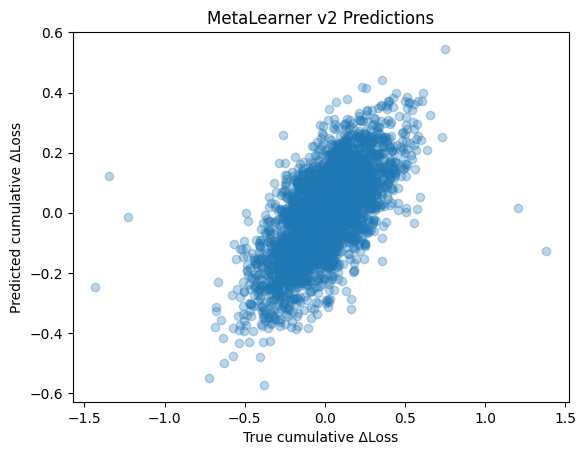

In [10]:
model.eval()
with torch.no_grad():
    preds = model(X_val).cpu().numpy()

plt.scatter(y_val.cpu().numpy(), preds, alpha=0.3)
plt.xlabel("True cumulative ΔLoss")
plt.ylabel("Predicted cumulative ΔLoss")
plt.title("MetaLearner v2 Predictions")
plt.show()

Device: cuda


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6464\39635425.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_gru_v2.pt", map_locati

Temporal GRU loaded.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

d:\all project\venv_cuda\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

d:\all project\venv_cuda\lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

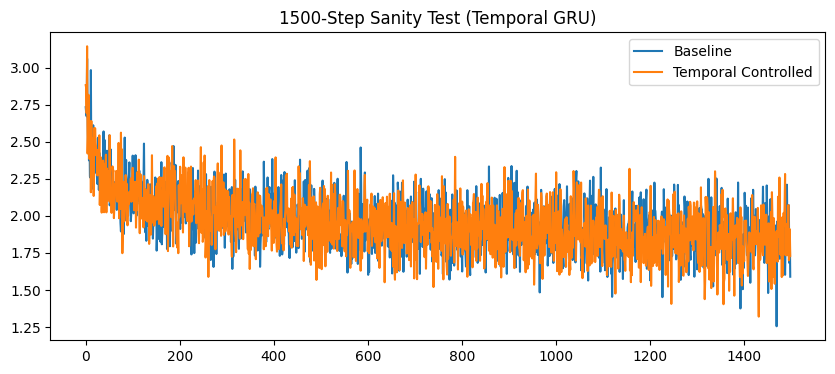

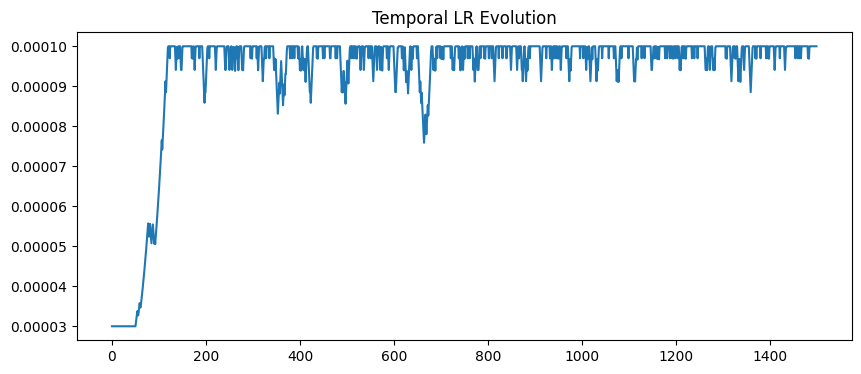

In [1]:
# ==============================
# 1️⃣ Imports
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import GPT2LMHeadModel, GPT2Tokenizer, DataCollatorForLanguageModeling
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==============================
# 2️⃣ Load TinyStories Subset
# ==============================

dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train[:5%]"
)

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True, remove_columns=["text"])
dataset.set_format("torch")

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

train_dataloader = DataLoader(
    dataset,
    shuffle=True,
    batch_size=4,
    collate_fn=data_collator
)

# ==============================
# 3️⃣ Utility Functions
# ==============================

def global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().norm(2).item() ** 2
    return total ** 0.5

def global_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.detach().norm(2).item() ** 2
    return total ** 0.5

def layer_grad_stats(model):
    norms = []
    for p in model.parameters():
        if p.grad is not None:
            norms.append(p.grad.detach().norm(2).item())
    if len(norms) == 0:
        return 0.0, 0.0
    return float(np.mean(norms)), float(np.std(norms))

# ==============================
# 4️⃣ Baseline Test
# ==============================

def run_baseline_test(max_steps=1500):

    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=3e-5)

    step = 0
    loss_history = []

    for batch in train_dataloader:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"]
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)

        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        step += 1

    return loss_history

# ==============================
# 5️⃣ Load Temporal GRU Model + Scaler
# ==============================

# ---- Load your trained GRU model ----
# Make sure these files exist in working directory:
# model_gru_v2.pt
# scaler_gru_v2.pkl

import joblib

class MetaLearnerGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

# adjust feature_dim if needed
feature_dim = 10

model = MetaLearnerGRU(feature_dim).to(device)
model.load_state_dict(torch.load("model_gru_v2.pt", map_location=device))
model.eval()

scaler = joblib.load("scaler_gru_v2.pkl")

print("Temporal GRU loaded.")

# ==============================
# 6️⃣ Temporal Controller Test
# ==============================

def run_temporal_meta_control_test(max_steps=1500):

    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_model.config.pad_token_id = tokenizer.eos_token_id
    gpt_model.to(device)
    gpt_model.train()

    base_lr = 3e-5
    optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=base_lr)

    adjust_pct = 0.03
    epsilon = 0.01
    min_lr = 1e-6
    max_lr = 1e-4
    warmup_steps = 50

    step = 0
    prev_loss = None
    state_buffer = []

    loss_history = []
    lr_history = []

    for batch in train_dataloader:

        if step >= max_steps:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"]
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)

        raw_loss = loss.item()
        grad_norm = global_grad_norm(gpt_model)
        weight_norm = global_weight_norm(gpt_model)
        lr_current = optimizer.param_groups[0]["lr"]
        update_ratio = (lr_current * grad_norm) / (weight_norm + 1e-9)
        layer_mean, layer_std = layer_grad_stats(gpt_model)

        delta_loss = 0.0 if prev_loss is None else raw_loss - prev_loss
        prev_loss = raw_loss
        step_fraction = step / max_steps

        state = np.array([
            raw_loss,
            delta_loss,
            lr_current,
            grad_norm,
            update_ratio,
            layer_mean,
            layer_std,
            base_lr,
            0,
            step_fraction
        ])

        state = np.nan_to_num(state)
        state_buffer.append(state)

        if len(state_buffer) > 4:
            state_buffer.pop(0)

        if len(state_buffer) == 4 and step > warmup_steps:

            seq = np.array(state_buffer)
            seq_flat = seq.reshape(-1, seq.shape[-1])
            seq_scaled = scaler.transform(seq_flat)
            seq_scaled = seq_scaled.reshape(1, 4, -1)

            seq_tensor = torch.tensor(seq_scaled, dtype=torch.float32).to(device)

            with torch.no_grad():
                pred = model(seq_tensor).item()

            if pred < -epsilon:
                new_lr = lr_current * (1 + adjust_pct)
            elif pred > epsilon:
                new_lr = lr_current * (1 - adjust_pct)
            else:
                new_lr = lr_current

            new_lr = max(min_lr, min(max_lr, new_lr))
            optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(raw_loss)
        lr_history.append(optimizer.param_groups[0]["lr"])

        step += 1

    return loss_history, lr_history

# ==============================
# 7️⃣ Run Sanity Test
# ==============================

baseline_loss = run_baseline_test()
temporal_loss, temporal_lr = run_temporal_meta_control_test()

# ==============================
# 8️⃣ Plot Results
# ==============================

plt.figure(figsize=(10,4))
plt.plot(baseline_loss, label="Baseline")
plt.plot(temporal_loss, label="Temporal Controlled")
plt.legend()
plt.title("1500-Step Sanity Test (Temporal GRU)")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(temporal_lr)
plt.title("Temporal LR Evolution")
plt.show()

In [2]:
pip install deepobs


   ---------- ----------------------------- 1/4 [seaborn]
   -------------------- ------------------- 2/4 [matplotlib2tikz]
   ------------------------------ --------- 3/4 [deepobs]
   ------------------------------ --------- 3/4 [deepobs]
   ------------------------------ --------- 3/4 [deepobs]
   ---------------------------------------- 4/4 [deepobs]

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

  Using cached ml_dtypes-0.5.4-cp310-cp310-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.7 MB 2.8 MB/s eta 0:01:58
   ---------------------------------------- 0.8/331.7 MB 1.9 MB/s eta 0:02:58
   ---------------------------------------- 1.6/331.7 MB 2.6 MB/s eta 0:02:06
   ---------------------------------------- 2.6/331.7 MB 3.3 MB/s eta 0:01:41
   ---------------------------------------- 3.7/331.7 MB 3.6 MB/s eta 0:01:31
    --------------------------------------- 4.7/331.7 MB 4.0 MB/s eta 0:01:23
    --------------------------------------- 6.3/331.7 MB 4.5 MB/s eta 0:01:13
    --------------------------------------- 7.6/331.7 MB 4.7 MB/s eta 0:01:10
   - -------------------------------------- 9.7/331.7 MB 5.3 MB/s eta 0:01:01
   - -------------------------------------- 11.8/331.7 MB 5.8 MB/s eta 0:00:56
   - -------------------------------------- 14.4/331.7 MB 6.5 MB/s eta 0:

In [2]:
pip install deepobs torchvision pandas tqdm

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
Note: you may need to restart the kernel to use updated packages.


 dataset creation

In [1]:
from deepobs.pytorch.testproblems import mnist_2c2d, cifar10_3c3d

print("Initializing MNIST...")
mnist_problem = mnist_2c2d(batch_size=128)

print("Initializing CIFAR10...")
cifar_problem = cifar10_3c3d(batch_size=128)

print("Datasets ready.")

Initializing MNIST...
Initializing CIFAR10...
Datasets ready.


In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import SGD, Adam
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Simple CNN (DeepOBS-like)
# ----------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ----------------------------
# Load MNIST
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# ----------------------------
# Regime Runner
# ----------------------------
def run_regime(
    lr,
    optimizer_type="adam",
    max_steps=3000,
    regime_name="regime",
    schedule=None,
    seed=0
):

    torch.manual_seed(seed)

    model = SimpleCNN().to(device)

    if optimizer_type == "adam":
        optimizer = Adam(model.parameters(), lr=lr)
    else:
        optimizer = SGD(model.parameters(), lr=lr)

    logs = []
    step = 0
    prev_loss = None

    while step < max_steps:

        for x, y in train_loader:

            if step >= max_steps:
                break

            x, y = x.to(device), y.to(device)

            # Optional schedule
            if schedule == "cosine":
                progress = step / max_steps
                new_lr = lr * 0.5 * (1 + np.cos(np.pi * progress))
                optimizer.param_groups[0]["lr"] = new_lr

            if schedule == "warmup":
                warmup_steps = 500
                if step < warmup_steps:
                    optimizer.param_groups[0]["lr"] = lr * (step / warmup_steps)
                else:
                    optimizer.param_groups[0]["lr"] = lr

            optimizer.zero_grad()

            outputs = model(x)
            loss = F.cross_entropy(outputs, y)
            loss.backward()

            grad_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm += p.grad.norm().item() ** 2
            grad_norm = grad_norm ** 0.5

            optimizer.step()

            delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
            prev_loss = loss.item()

            logs.append({
                "loss": loss.item(),
                "delta_loss": delta_loss,
                "lr": optimizer.param_groups[0]["lr"],
                "grad_norm": grad_norm,
                "step": step,
                "regime": regime_name
            })

            step += 1

    df = pd.DataFrame(logs)
    df["step_fraction"] = df["step"] / df["step"].max()

    return df

In [16]:
regimes = []

# Stable regimes
regimes.append(run_regime(1e-3, "adam", regime_name="adam_lr1e3"))
regimes.append(run_regime(5e-3, "adam", regime_name="adam_lr5e3"))

# Unstable
regimes.append(run_regime(0.1, "sgd", regime_name="sgd_lr1e1"))
regimes.append(run_regime(0.3, "sgd", regime_name="sgd_lr3e1"))

# Cosine decay
regimes.append(run_regime(1e-2, "sgd", schedule="cosine", regime_name="sgd_cos"))

# Warmup
regimes.append(run_regime(1e-2, "adam", schedule="warmup", regime_name="adam_warm"))

# Repeat with different seeds
regimes.append(run_regime(1e-3, "adam", regime_name="adam_seed1", seed=1))
regimes.append(run_regime(1e-3, "adam", regime_name="adam_seed2", seed=2))

df_all = pd.concat(regimes, ignore_index=True)
df_all.to_csv("meta_dataset_external_v2.csv", index=False)

print("Rows:", len(df_all))

Rows: 24000


In [22]:
import pandas as pd

df_ext = pd.read_csv("meta_dataset_external_v2.csv")
df_gpt = pd.read_csv("meta_dataset_clean.csv")  # your GPT2 dataset

# Keep common columns only
common_cols = list(set(df_ext.columns).intersection(df_gpt.columns))

df_ext = df_ext[common_cols]
df_gpt = df_gpt[common_cols]

df_merged = pd.concat([df_ext, df_gpt], ignore_index=True)

df_merged.to_csv("meta_dataset_merged_v3.csv", index=False)

print("Merged rows:", len(df_merged))

Merged rows: 25245


In [26]:
print(df_merged.columns)

Index(['delta_loss', 'lr', 'loss', 'grad_norm'], dtype='object')


In [27]:
import numpy as np

window_size = 10
future_horizon = 1

feature_cols = ['loss', 'lr', 'grad_norm']

values = df_merged[feature_cols].values
targets = df_merged["delta_loss"].values

X_seq = []
y_seq = []

for i in range(len(values) - window_size - future_horizon):
    X_seq.append(values[i:i+window_size])
    y_seq.append(targets[i+window_size])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)

Sequence shape: (25234, 10, 3)


In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# ===============================
# Normalize Features
# ===============================

scaler = StandardScaler()
X_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

joblib.dump(scaler, "scaler_meta_v2.pkl")

# ===============================
# Train / Val Split
# ===============================

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_seq, test_size=0.2, random_state=42
)

# ===============================
# Dataset Class
# ===============================

class MetaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MetaDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(MetaDataset(X_val, y_val), batch_size=128)

# ===============================
# GRU v2 Model
# ===============================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=128):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze()

model = TemporalMetaLearner().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===============================
# Training Loop
# ===============================

best_val = float("inf")

for epoch in range(40):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "temporal_meta_v2.pt")

Epoch 1 | Train 0.034961 | Val 0.030787
Epoch 2 | Train 0.030453 | Val 0.029801
Epoch 3 | Train 0.029721 | Val 0.030165
Epoch 4 | Train 0.029244 | Val 0.029446
Epoch 5 | Train 0.029612 | Val 0.029368
Epoch 6 | Train 0.028767 | Val 0.029681
Epoch 7 | Train 0.028889 | Val 0.029174
Epoch 8 | Train 0.028389 | Val 0.032495
Epoch 9 | Train 0.028864 | Val 0.030036
Epoch 10 | Train 0.028087 | Val 0.029066
Epoch 11 | Train 0.027913 | Val 0.032688
Epoch 12 | Train 0.027516 | Val 0.030373
Epoch 13 | Train 0.027378 | Val 0.030664
Epoch 14 | Train 0.026761 | Val 0.030441
Epoch 15 | Train 0.025870 | Val 0.030603
Epoch 16 | Train 0.025613 | Val 0.030846
Epoch 17 | Train 0.025170 | Val 0.032835
Epoch 18 | Train 0.024410 | Val 0.031567
Epoch 19 | Train 0.023839 | Val 0.034004
Epoch 20 | Train 0.023079 | Val 0.032227
Epoch 21 | Train 0.022424 | Val 0.035920
Epoch 22 | Train 0.021148 | Val 0.034484
Epoch 23 | Train 0.019839 | Val 0.035477
Epoch 24 | Train 0.018228 | Val 0.033864
Epoch 25 | Train 0.017178

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================
# NORMALIZATION
# =====================================

scaler = StandardScaler()
X_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

joblib.dump(scaler, "scaler_meta_v2.pkl")

# =====================================
# TRAIN / VALIDATION SPLIT
# =====================================

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_seq, test_size=0.2, random_state=42
)

# =====================================
# DATASET CLASS
# =====================================

class MetaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MetaDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(MetaDataset(X_val, y_val), batch_size=128)

# =====================================
# GRU v2.1 MODEL (Regularized)
# =====================================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze()

model = TemporalMetaLearner().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# =====================================
# TRAINING LOOP WITH EARLY STOPPING
# =====================================

best_val = float("inf")
patience = 6
no_improve = 0
max_epochs = 50

for epoch in range(max_epochs):

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    # ---- EARLY STOPPING ----
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "temporal_meta_v2_1.pt")
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered.")
        break

print("Training complete.")

Epoch 1 | Train 0.043512 | Val 0.030275
Epoch 2 | Train 0.030746 | Val 0.029299
Epoch 3 | Train 0.030474 | Val 0.029591
Epoch 4 | Train 0.029765 | Val 0.029374
Epoch 5 | Train 0.029163 | Val 0.029347
Epoch 6 | Train 0.029081 | Val 0.030241
Epoch 7 | Train 0.029486 | Val 0.029378
Epoch 8 | Train 0.029248 | Val 0.029399
Early stopping triggered.
Training complete.


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# LOAD SCALER + META MODEL
# =====================================================

scaler = joblib.load("scaler_meta_v2.pkl")

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

meta_model = TemporalMetaLearner().to(device)
meta_model.load_state_dict(torch.load("temporal_meta_v2_1.pt"))
meta_model.eval()

# =====================================================
# SIMPLE CNN
# =====================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# =====================================================
# LOAD MNIST
# =====================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# =====================================================
# HELPER FUNCTIONS
# =====================================================

def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

# =====================================================
# BASELINE SGD TEST
# =====================================================

def run_baseline_sgd(max_steps=1500, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    losses = []

    step = 0
    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        step += 1

    return losses

# =====================================================
# META-CONTROLLED SGD TEST
# =====================================================

def run_meta_control_sgd(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    window_size = 10
    state_buffer = []

    losses = []
    lrs = []

    step = 0
    prev_loss = None

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()

        grad_norm = compute_grad_norm(model)
        current_lr = optimizer.param_groups[0]["lr"]

        delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
        prev_loss = loss.item()

        # Build state vector
        state = np.array([[
            loss.item(),
            current_lr,
            grad_norm
        ]])

        state = scaler.transform(state)

        state_buffer.append(state[0])

        if len(state_buffer) >= window_size:

            window = np.array(state_buffer[-window_size:])
            window = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred_delta = meta_model(window)

            # LR update rule
            alpha = 0.2
            multiplier = 1 - alpha * torch.tanh(pred_delta)
            multiplier = torch.clamp(multiplier, 0.9, 1.1)

            new_lr = current_lr * multiplier.item()

            # clamp safety
            new_lr = max(1e-4, min(0.1, new_lr))

            optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()

        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]["lr"])

        step += 1

    return losses, lrs

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6892\4160454129.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("temporal_meta_v2_1.pt"

In [34]:
baseline_losses = run_baseline_sgd()
meta_losses, meta_lrs = run_meta_control_sgd()

print("Baseline final loss:", baseline_losses[-1])
print("Meta final loss:", meta_losses[-1])

Baseline final loss: 0.3855786621570587
Meta final loss: 0.19083909690380096


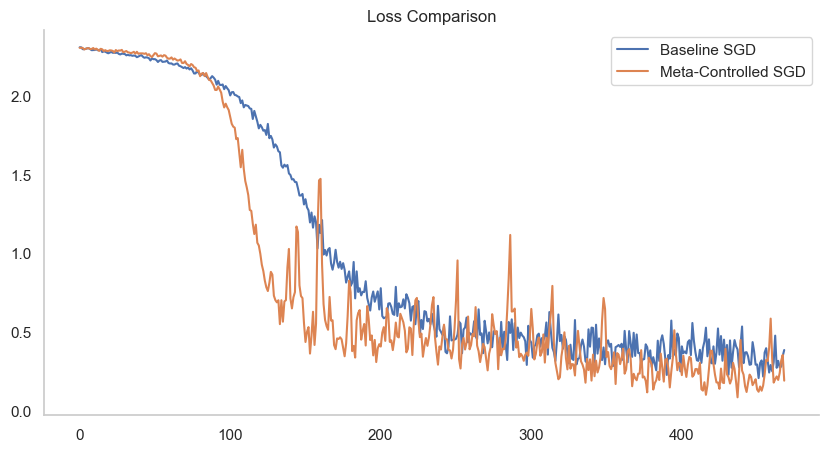

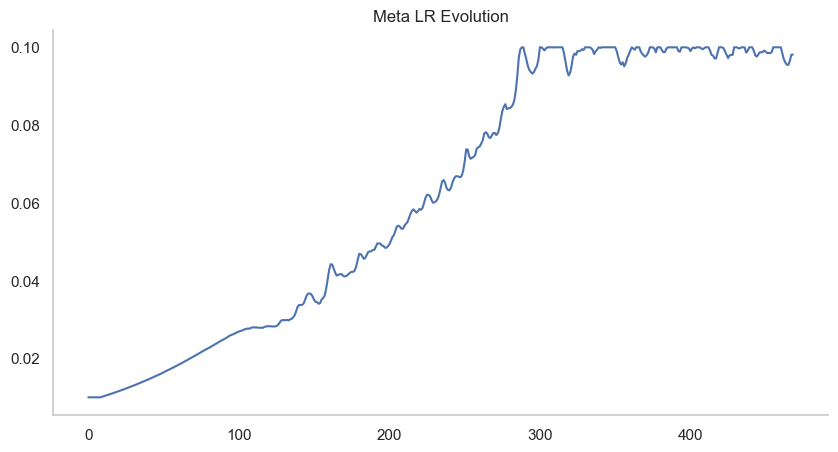

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(baseline_losses, label="Baseline SGD")
plt.plot(meta_losses, label="Meta-Controlled SGD")
plt.legend()
plt.title("Loss Comparison")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(meta_lrs)
plt.title("Meta LR Evolution")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6892\3673467549.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("temporal_meta_v2_1.pt"

Baseline final loss: 0.44798555970191956
Meta final loss: 0.15039514005184174
Baseline mean loss: 0.8983600262576329
Meta mean loss: 0.7927061353982893


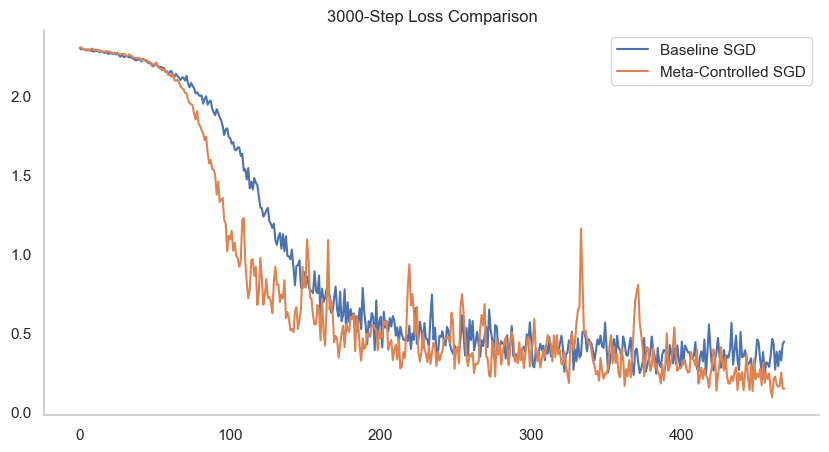

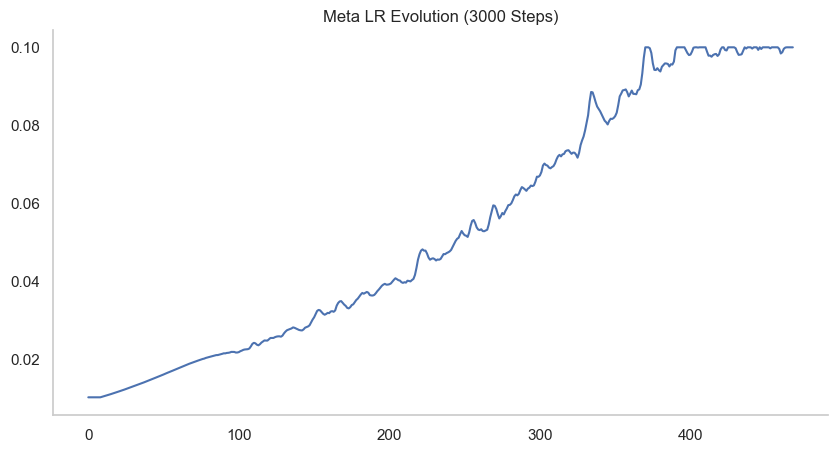

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# LOAD SCALER + TEMPORAL META MODEL
# =====================================================

scaler = joblib.load("scaler_meta_v2.pkl")

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

meta_model = TemporalMetaLearner().to(device)
meta_model.load_state_dict(torch.load("temporal_meta_v2_1.pt"))
meta_model.eval()

# =====================================================
# SIMPLE CNN
# =====================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# =====================================================
# MNIST LOADING
# =====================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# =====================================================
# HELPER
# =====================================================

def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

# =====================================================
# BASELINE SGD (3000 steps)
# =====================================================

def run_baseline_sgd(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    losses = []
    step = 0

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        step += 1

    return losses

# =====================================================
# META-CONTROLLED SGD (3000 steps)
# =====================================================

def run_meta_control_sgd(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    window_size = 10
    state_buffer = []

    losses = []
    lrs = []

    step = 0
    prev_loss = None

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()

        grad_norm = compute_grad_norm(model)
        current_lr = optimizer.param_groups[0]["lr"]

        delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
        prev_loss = loss.item()

        # Build feature state
        state = np.array([[loss.item(), current_lr, grad_norm]])
        state = scaler.transform(state)

        state_buffer.append(state[0])

        # Only update LR once buffer full
        if len(state_buffer) >= window_size:

            window = np.array(state_buffer[-window_size:])
            window = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred_delta = meta_model(window)

            alpha = 0.2
            multiplier = 1 - alpha * torch.tanh(pred_delta)
            multiplier = torch.clamp(multiplier, 0.9, 1.1)

            new_lr = current_lr * multiplier.item()

            # Safety clamp
            new_lr = max(1e-4, min(0.1, new_lr))
            optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()

        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]["lr"])

        step += 1

    return losses, lrs

# =====================================================
# RUN 3000-STEP BENCHMARK
# =====================================================

baseline_losses = run_baseline_sgd(max_steps=3000)
meta_losses, meta_lrs = run_meta_control_sgd(max_steps=3000)

print("Baseline final loss:", baseline_losses[-1])
print("Meta final loss:", meta_losses[-1])

# =====================================================
# METRICS
# =====================================================

baseline_mean = np.mean(baseline_losses)
meta_mean = np.mean(meta_losses)

print("Baseline mean loss:", baseline_mean)
print("Meta mean loss:", meta_mean)

# =====================================================
# PLOTS
# =====================================================

plt.figure(figsize=(10,5))
plt.plot(baseline_losses, label="Baseline SGD")
plt.plot(meta_losses, label="Meta-Controlled SGD")
plt.legend()
plt.title("3000-Step Loss Comparison")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(meta_lrs)
plt.title("Meta LR Evolution (3000 Steps)")
plt.show()

Baseline Adam final loss: 0.07910836488008499
Meta Adam final loss: 0.04134875908493996
Baseline Adam mean loss: 0.18223736237988733
Meta Adam mean loss: 0.17625098251231286


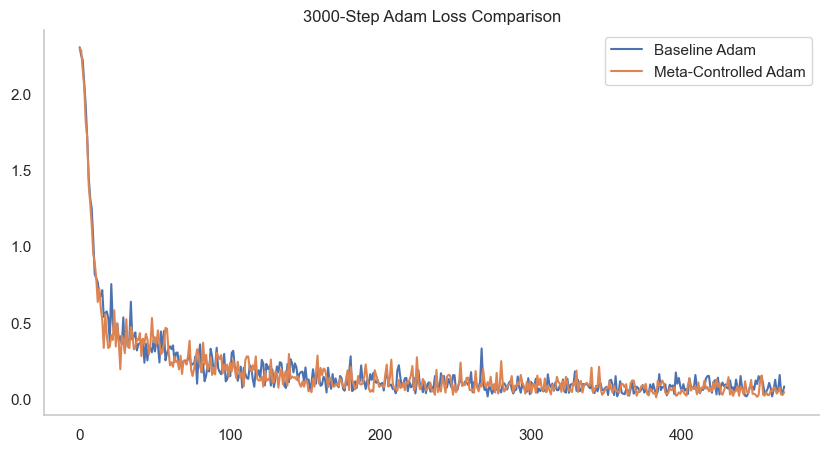

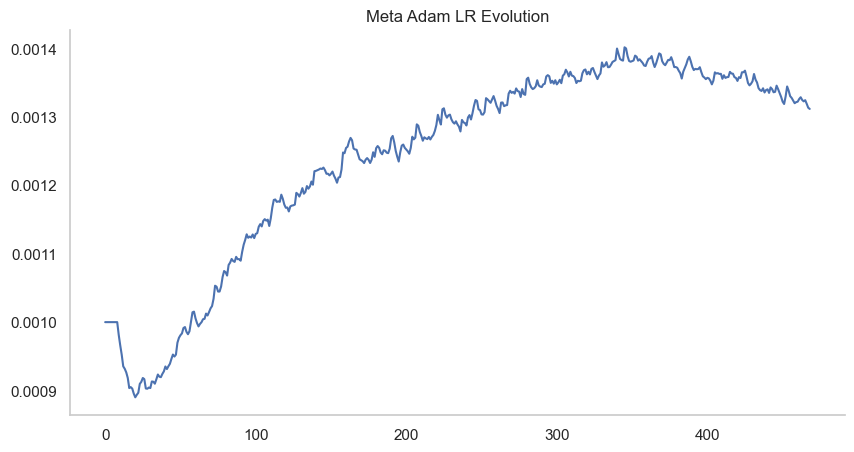

In [38]:
# =====================================================
# BASELINE ADAM (3000 steps)
# =====================================================

def run_baseline_adam(max_steps=3000, base_lr=1e-3):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)

    losses = []
    step = 0

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        step += 1

    return losses


# =====================================================
# META-CONTROLLED ADAM (3000 steps)
# =====================================================

def run_meta_control_adam(max_steps=3000, base_lr=1e-3):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)

    window_size = 10
    state_buffer = []

    losses = []
    lrs = []

    step = 0
    prev_loss = None

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()

        grad_norm = compute_grad_norm(model)
        current_lr = optimizer.param_groups[0]["lr"]

        delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
        prev_loss = loss.item()

        state = np.array([[loss.item(), current_lr, grad_norm]])
        state = scaler.transform(state)

        state_buffer.append(state[0])

        if len(state_buffer) >= window_size:

            window = np.array(state_buffer[-window_size:])
            window = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred_delta = meta_model(window)

            alpha = 0.15  # smaller alpha for Adam (more sensitive)
            multiplier = 1 - alpha * torch.tanh(pred_delta)
            multiplier = torch.clamp(multiplier, 0.9, 1.1)

            new_lr = current_lr * multiplier.item()

            # Adam safer range
            new_lr = max(1e-5, min(5e-3, new_lr))

            optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()

        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]["lr"])

        step += 1

    return losses, lrs


# =====================================================
# RUN 3000-STEP ADAM BENCHMARK
# =====================================================

baseline_adam = run_baseline_adam()
meta_adam, meta_adam_lrs = run_meta_control_adam()

print("Baseline Adam final loss:", baseline_adam[-1])
print("Meta Adam final loss:", meta_adam[-1])

print("Baseline Adam mean loss:", np.mean(baseline_adam))
print("Meta Adam mean loss:", np.mean(meta_adam))


# =====================================================
# PLOTS
# =====================================================

plt.figure(figsize=(10,5))
plt.plot(baseline_adam, label="Baseline Adam")
plt.plot(meta_adam, label="Meta-Controlled Adam")
plt.legend()
plt.title("3000-Step Adam Loss Comparison")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(meta_adam_lrs)
plt.title("Meta Adam LR Evolution")
plt.show()

In [39]:
# =====================================================
# METALEARNER v2.2 FULL PIPELINE (WITH UPDATE_RATIO)
# =====================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# SIMPLE CNN FOR DATA GENERATION
# =====================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# =====================================================
# LOAD MNIST
# =====================================================

transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# =====================================================
# HELPER FUNCTIONS
# =====================================================

def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

# =====================================================
# GENERATE META DATASET (SGD REGIMES)
# =====================================================

def generate_meta_dataset(max_steps=2000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    records = []
    prev_loss = None
    step = 0

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()

        grad_norm = compute_grad_norm(model)
        weight_norm = compute_weight_norm(model)
        current_lr = optimizer.param_groups[0]["lr"]

        update_ratio = (current_lr * grad_norm) / (weight_norm + 1e-9)

        delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
        prev_loss = loss.item()

        records.append([
            loss.item(),
            delta_loss,
            current_lr,
            grad_norm,
            update_ratio
        ])

        optimizer.step()
        step += 1

    columns = ["loss", "delta_loss", "lr", "grad_norm", "update_ratio"]
    df = pd.DataFrame(records, columns=columns)

    df.to_csv("meta_dataset_v2_2.csv", index=False)
    print("Dataset generated:", df.shape)

    return df

# Generate dataset
df = generate_meta_dataset()

# =====================================================
# BUILD TEMPORAL SEQUENCES
# =====================================================

window_size = 10
feature_cols = ['loss', 'lr', 'grad_norm', 'update_ratio']

values = df[feature_cols].values
targets = df["delta_loss"].values

X_seq = []
y_seq = []

for i in range(len(values) - window_size - 1):
    X_seq.append(values[i:i+window_size])
    y_seq.append(targets[i+window_size])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)

# =====================================================
# NORMALIZE
# =====================================================

scaler = StandardScaler()
X_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

joblib.dump(scaler, "scaler_meta_v2_2.pkl")

# =====================================================
# TRAIN/VAL SPLIT
# =====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_seq, test_size=0.2, random_state=42
)

class MetaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_meta = DataLoader(MetaDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader_meta = DataLoader(MetaDataset(X_val, y_val), batch_size=128)

# =====================================================
# GRU v2.2 MODEL (input_dim=4)
# =====================================================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

model_meta = TemporalMetaLearner().to(device)

criterion = nn.MSELoss()
optimizer_meta = torch.optim.Adam(
    model_meta.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# =====================================================
# TRAIN METALEARNER
# =====================================================

best_val = float("inf")
patience = 6
no_improve = 0

for epoch in range(40):

    model_meta.train()
    train_loss = 0

    for xb, yb in train_loader_meta:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_meta.zero_grad()
        preds = model_meta(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_meta.parameters(), 1.0)
        optimizer_meta.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_meta)

    model_meta.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader_meta:
            xb, yb = xb.to(device), yb.to(device)
            preds = model_meta(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader_meta)

    print(f"Epoch {epoch+1} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_meta.state_dict(), "temporal_meta_v2_2.pt")
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered.")
        break

print("MetaLearner v2.2 training complete.")

Dataset generated: (469, 5)
Sequence shape: (458, 10, 4)
Epoch 1 | Train 0.006816 | Val 0.004297
Epoch 2 | Train 0.005633 | Val 0.005440
Epoch 3 | Train 0.005642 | Val 0.004263
Epoch 4 | Train 0.005084 | Val 0.004111
Epoch 5 | Train 0.005206 | Val 0.004306
Epoch 6 | Train 0.005373 | Val 0.004035
Epoch 7 | Train 0.004848 | Val 0.004102
Epoch 8 | Train 0.005041 | Val 0.004387
Epoch 9 | Train 0.004890 | Val 0.004232
Epoch 10 | Train 0.004867 | Val 0.004064
Epoch 11 | Train 0.004911 | Val 0.004106
Epoch 12 | Train 0.004927 | Val 0.004025
Epoch 13 | Train 0.004747 | Val 0.004023
Epoch 14 | Train 0.004670 | Val 0.004075
Epoch 15 | Train 0.004576 | Val 0.004129
Epoch 16 | Train 0.004816 | Val 0.004127
Epoch 17 | Train 0.004504 | Val 0.004048
Epoch 18 | Train 0.004753 | Val 0.004040
Epoch 19 | Train 0.004756 | Val 0.004067
Early stopping triggered.
MetaLearner v2.2 training complete.


In [40]:
# =====================================================
# METALEARNER v2.2 MULTI-REGIME DATASET BUILDER
# =====================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# SIMPLE CNN
# =====================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# =====================================================
# LOAD MNIST
# =====================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# =====================================================
# HELPERS
# =====================================================

def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

# =====================================================
# MULTI-REGIME GENERATOR
# =====================================================

def generate_multi_regime_dataset():

    sgd_lrs = [0.005, 0.01, 0.05]
    adam_lrs = [5e-4, 1e-3, 2e-3]
    seeds = [42, 123, 999]
    epochs = 3

    records = []

    for seed in seeds:

        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        # ===============================
        # SGD Regimes
        # ===============================

        for lr in sgd_lrs:

            model = SimpleCNN().to(device)
            optimizer = torch.optim.SGD(model.parameters(), lr=lr)

            prev_loss = None

            for epoch in range(epochs):
                for x, y in train_loader:

                    x, y = x.to(device), y.to(device)

                    optimizer.zero_grad()
                    outputs = model(x)
                    loss = F.cross_entropy(outputs, y)
                    loss.backward()

                    grad_norm = compute_grad_norm(model)
                    weight_norm = compute_weight_norm(model)
                    update_ratio = (lr * grad_norm) / (weight_norm + 1e-9)

                    delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
                    prev_loss = loss.item()

                    records.append([
                        loss.item(),
                        delta_loss,
                        lr,
                        grad_norm,
                        update_ratio,
                        "sgd"
                    ])

                    optimizer.step()

        # ===============================
        # ADAM Regimes
        # ===============================

        for lr in adam_lrs:

            model = SimpleCNN().to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

            prev_loss = None

            for epoch in range(epochs):
                for x, y in train_loader:

                    x, y = x.to(device), y.to(device)

                    optimizer.zero_grad()
                    outputs = model(x)
                    loss = F.cross_entropy(outputs, y)
                    loss.backward()

                    grad_norm = compute_grad_norm(model)
                    weight_norm = compute_weight_norm(model)
                    update_ratio = (lr * grad_norm) / (weight_norm + 1e-9)

                    delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
                    prev_loss = loss.item()

                    records.append([
                        loss.item(),
                        delta_loss,
                        lr,
                        grad_norm,
                        update_ratio,
                        "adam"
                    ])

                    optimizer.step()

    columns = ["loss", "delta_loss", "lr", "grad_norm", "update_ratio", "optimizer"]
    df = pd.DataFrame(records, columns=columns)

    df.to_csv("meta_dataset_v2_2_multi.csv", index=False)

    print("Final dataset shape:", df.shape)
    return df


# =====================================================
# GENERATE DATASET
# =====================================================

df_multi = generate_multi_regime_dataset()

Final dataset shape: (25326, 6)


In [41]:
# =====================================================
# BUILD TEMPORAL DATASET FROM MULTI-REGIME DATA
# =====================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv("meta_dataset_v2_2_multi.csv")

# Sort to maintain temporal continuity inside regimes
df = df.reset_index(drop=True)

feature_cols = ['loss', 'lr', 'grad_norm', 'update_ratio']

window_size = 10

X_seq = []
y_seq = []

# IMPORTANT: Build sequences inside each optimizer separately
for opt_name in df["optimizer"].unique():

    df_opt = df[df["optimizer"] == opt_name].reset_index(drop=True)

    values = df_opt[feature_cols].values
    targets = df_opt["delta_loss"].values

    for i in range(len(values) - window_size - 1):
        X_seq.append(values[i:i+window_size])
        y_seq.append(targets[i+window_size])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)

# =====================================================
# NORMALIZE FEATURES
# =====================================================

scaler = StandardScaler()
X_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

joblib.dump(scaler, "scaler_meta_v2_2.pkl")

# =====================================================
# TRAIN/VAL SPLIT
# =====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_seq, test_size=0.2, random_state=42
)

class MetaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_meta = DataLoader(MetaDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader_meta = DataLoader(MetaDataset(X_val, y_val), batch_size=256)

# =====================================================
# GRU v2.2 MODEL (input_dim=4)
# =====================================================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

model_meta = TemporalMetaLearner().to(device)

criterion = nn.MSELoss()
optimizer_meta = torch.optim.Adam(
    model_meta.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# =====================================================
# TRAIN METALEARNER v2.2
# =====================================================

best_val = float("inf")
patience = 6
no_improve = 0

for epoch in range(50):

    model_meta.train()
    train_loss = 0

    for xb, yb in train_loader_meta:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_meta.zero_grad()
        preds = model_meta(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_meta.parameters(), 1.0)
        optimizer_meta.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_meta)

    model_meta.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader_meta:
            xb, yb = xb.to(device), yb.to(device)
            preds = model_meta(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader_meta)

    print(f"Epoch {epoch+1} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_meta.state_dict(), "temporal_meta_v2_2.pt")
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered.")
        break

print("MetaLearner v2.2 training complete.")

Sequence shape: (25304, 10, 4)
Epoch 1 | Train 0.006875 | Val 0.005105
Epoch 2 | Train 0.005236 | Val 0.005016
Epoch 3 | Train 0.005093 | Val 0.005004
Epoch 4 | Train 0.005022 | Val 0.004986
Epoch 5 | Train 0.004924 | Val 0.004851
Epoch 6 | Train 0.004886 | Val 0.004770
Epoch 7 | Train 0.004833 | Val 0.004752
Epoch 8 | Train 0.004926 | Val 0.004784
Epoch 9 | Train 0.004887 | Val 0.004699
Epoch 10 | Train 0.004801 | Val 0.004676
Epoch 11 | Train 0.004759 | Val 0.004679
Epoch 12 | Train 0.004699 | Val 0.004657
Epoch 13 | Train 0.004659 | Val 0.004610
Epoch 14 | Train 0.004675 | Val 0.004712
Epoch 15 | Train 0.004720 | Val 0.004572
Epoch 16 | Train 0.004581 | Val 0.004559
Epoch 17 | Train 0.004594 | Val 0.004502
Epoch 18 | Train 0.004594 | Val 0.004549
Epoch 19 | Train 0.004536 | Val 0.004500
Epoch 20 | Train 0.004501 | Val 0.004443
Epoch 21 | Train 0.004497 | Val 0.004452
Epoch 22 | Train 0.004493 | Val 0.004425
Epoch 23 | Train 0.004486 | Val 0.004446
Epoch 24 | Train 0.004476 | Val 0.0

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6892\2873915587.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("temporal_meta_v2_2.pt"

MetaLearner v2.2 loaded.
Baseline final loss: 0.30058956146240234
Meta final loss: 0.3129953444004059
Baseline mean loss: 0.9266061521351718
Meta mean loss: 0.9648404292015633


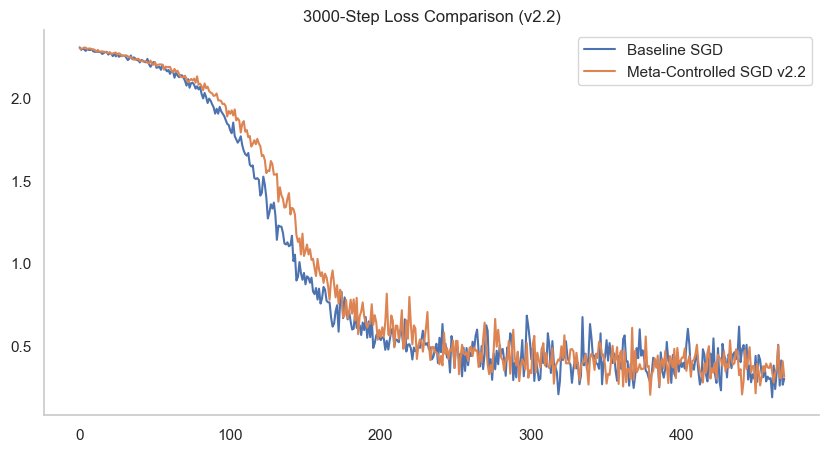

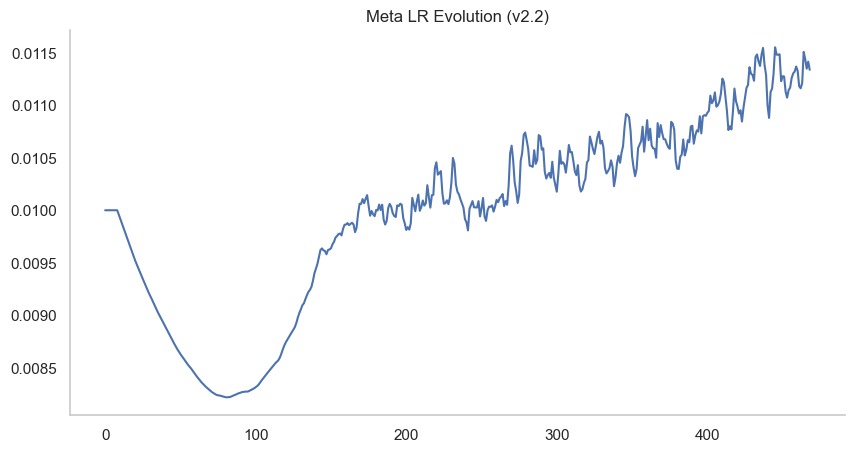

In [42]:
# =====================================================
# METALEARNER v2.2 — FULL BENCHMARK (SGD, 3000 STEPS)
# =====================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# LOAD SCALER + META MODEL v2.2
# =====================================================

scaler = joblib.load("scaler_meta_v2_2.pkl")

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

meta_model = TemporalMetaLearner().to(device)
meta_model.load_state_dict(torch.load("temporal_meta_v2_2.pt"))
meta_model.eval()

print("MetaLearner v2.2 loaded.")

# =====================================================
# SIMPLE CNN
# =====================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# =====================================================
# MNIST
# =====================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# =====================================================
# HELPER FUNCTIONS
# =====================================================

def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

# =====================================================
# BASELINE SGD (3000 STEPS)
# =====================================================

def run_baseline_sgd(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    losses = []
    step = 0

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        step += 1

    return losses

# =====================================================
# META-CONTROLLED SGD v2.2 (3000 STEPS)
# =====================================================

def run_meta_control_sgd(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    window_size = 10
    state_buffer = []

    losses = []
    lrs = []

    step = 0
    prev_loss = None

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()

        grad_norm = compute_grad_norm(model)
        weight_norm = compute_weight_norm(model)
        current_lr = optimizer.param_groups[0]["lr"]

        update_ratio = (current_lr * grad_norm) / (weight_norm + 1e-9)

        delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
        prev_loss = loss.item()

        # Build state vector (4 features)
        state = np.array([[loss.item(), current_lr, grad_norm, update_ratio]])
        state = scaler.transform(state)

        state_buffer.append(state[0])

        if len(state_buffer) >= window_size:

            window = np.array(state_buffer[-window_size:])
            window = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred_delta = meta_model(window)

            alpha = 0.2
            multiplier = 1 - alpha * torch.tanh(pred_delta)
            multiplier = torch.clamp(multiplier, 0.9, 1.1)

            new_lr = current_lr * multiplier.item()

            # Safety clamp
            new_lr = max(1e-4, min(0.1, new_lr))
            optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()

        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]["lr"])

        step += 1

    return losses, lrs

# =====================================================
# RUN BENCHMARK
# =====================================================

baseline_losses = run_baseline_sgd()
meta_losses, meta_lrs = run_meta_control_sgd()

print("Baseline final loss:", baseline_losses[-1])
print("Meta final loss:", meta_losses[-1])

print("Baseline mean loss:", np.mean(baseline_losses))
print("Meta mean loss:", np.mean(meta_losses))

# =====================================================
# PLOTS
# =====================================================

plt.figure(figsize=(10,5))
plt.plot(baseline_losses, label="Baseline SGD")
plt.plot(meta_losses, label="Meta-Controlled SGD v2.2")
plt.legend()
plt.title("3000-Step Loss Comparison (v2.2)")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(meta_lrs)
plt.title("Meta LR Evolution (v2.2)")
plt.show()

In [43]:
# =====================================================
# METALEARNER v2.3 — 5-STEP FUTURE TARGET
# =====================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# LOAD MULTI-REGIME DATASET
# =====================================================

df = pd.read_csv("meta_dataset_v2_2_multi.csv")
df = df.reset_index(drop=True)

feature_cols = ['loss', 'lr', 'grad_norm', 'update_ratio']

window_size = 10
future_horizon = 5   # 👈 NEW

X_seq = []
y_seq = []

# Build sequences per optimizer
for opt_name in df["optimizer"].unique():

    df_opt = df[df["optimizer"] == opt_name].reset_index(drop=True)

    values = df_opt[feature_cols].values
    delta_losses = df_opt["delta_loss"].values

    for i in range(len(values) - window_size - future_horizon):

        X_seq.append(values[i:i+window_size])

        # 5-step cumulative future loss
        future_delta = delta_losses[i+window_size : i+window_size+future_horizon]
        y_seq.append(np.sum(future_delta))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)
print("Target shape:", y_seq.shape)

# =====================================================
# NORMALIZATION
# =====================================================

scaler = StandardScaler()
X_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

joblib.dump(scaler, "scaler_meta_v2_3.pkl")

# =====================================================
# SPLIT
# =====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_seq, test_size=0.2, random_state=42
)

class MetaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_meta = DataLoader(MetaDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader_meta = DataLoader(MetaDataset(X_val, y_val), batch_size=256)

# =====================================================
# GRU MODEL
# =====================================================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

model_meta = TemporalMetaLearner().to(device)

criterion = nn.MSELoss()
optimizer_meta = torch.optim.Adam(
    model_meta.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# =====================================================
# TRAIN
# =====================================================

best_val = float("inf")
patience = 6
no_improve = 0

for epoch in range(50):

    model_meta.train()
    train_loss = 0

    for xb, yb in train_loader_meta:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_meta.zero_grad()
        preds = model_meta(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_meta.parameters(), 1.0)
        optimizer_meta.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_meta)

    model_meta.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader_meta:
            xb, yb = xb.to(device), yb.to(device)
            preds = model_meta(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader_meta)

    print(f"Epoch {epoch+1} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_meta.state_dict(), "temporal_meta_v2_3.pt")
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered.")
        break

print("MetaLearner v2.3 training complete.")

Sequence shape: (25296, 10, 4)
Target shape: (25296,)
Epoch 1 | Train 0.008516 | Val 0.007608
Epoch 2 | Train 0.007345 | Val 0.006948
Epoch 3 | Train 0.006973 | Val 0.006597
Epoch 4 | Train 0.006685 | Val 0.006314
Epoch 5 | Train 0.006503 | Val 0.006206
Epoch 6 | Train 0.006411 | Val 0.006301
Epoch 7 | Train 0.006307 | Val 0.006014
Epoch 8 | Train 0.006224 | Val 0.005983
Epoch 9 | Train 0.006130 | Val 0.006152
Epoch 10 | Train 0.006100 | Val 0.005619
Epoch 11 | Train 0.005973 | Val 0.005607
Epoch 12 | Train 0.005856 | Val 0.005504
Epoch 13 | Train 0.005830 | Val 0.005528
Epoch 14 | Train 0.005743 | Val 0.005452
Epoch 15 | Train 0.005641 | Val 0.005387
Epoch 16 | Train 0.005616 | Val 0.005271
Epoch 17 | Train 0.005480 | Val 0.005045
Epoch 18 | Train 0.005362 | Val 0.005088
Epoch 19 | Train 0.005321 | Val 0.004777
Epoch 20 | Train 0.005146 | Val 0.004683
Epoch 21 | Train 0.005030 | Val 0.004623
Epoch 22 | Train 0.005004 | Val 0.004587
Epoch 23 | Train 0.004934 | Val 0.004501
Epoch 24 | T

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6892\1466040195.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("temporal_meta_v2_3.pt"

MetaLearner v2.3 loaded.

===== RESULTS =====
Baseline final loss: 0.37088266015052795
Meta final loss: 0.2715413570404053
Baseline mean loss: 1.4427411809786042
Meta mean loss: 1.1647383309503607


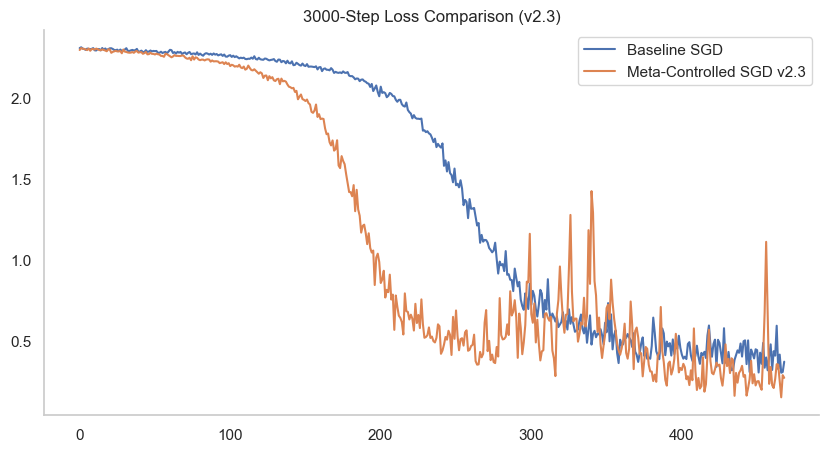

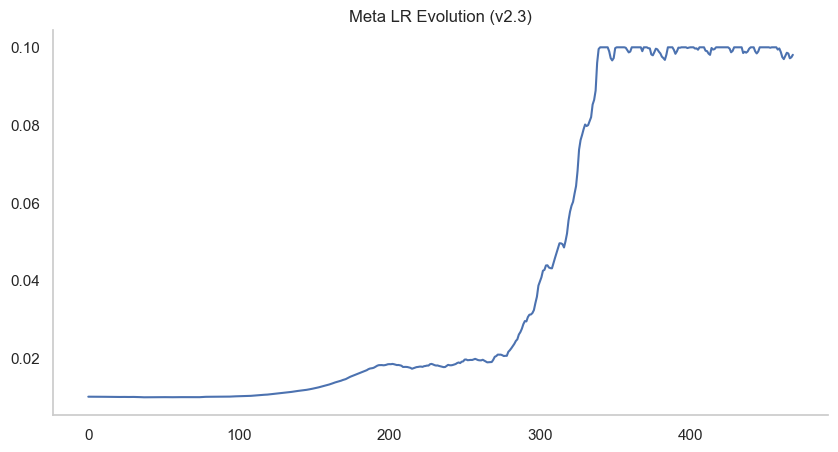

In [44]:
# =====================================================
# METALEARNER v2.3 — 5-STEP TREND CONTROLLER (SGD)
# 3000 STEP BENCHMARK
# =====================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# LOAD SCALER + META MODEL v2.3
# =====================================================

scaler = joblib.load("scaler_meta_v2_3.pkl")

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

meta_model = TemporalMetaLearner().to(device)
meta_model.load_state_dict(torch.load("temporal_meta_v2_3.pt"))
meta_model.eval()

print("MetaLearner v2.3 loaded.")

# =====================================================
# SIMPLE CNN
# =====================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# =====================================================
# MNIST
# =====================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# =====================================================
# HELPERS
# =====================================================

def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

# =====================================================
# BASELINE SGD
# =====================================================

def run_baseline_sgd(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    losses = []
    step = 0

    for x, y in train_loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        step += 1

    return losses

# =====================================================
# META-CONTROLLED SGD (v2.3)
# =====================================================

def run_meta_control_sgd_v2_3(max_steps=3000, base_lr=0.01):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)

    window_size = 10
    state_buffer = []

    losses = []
    lrs = []

    step = 0

    for x, y in train_loader:

        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = F.cross_entropy(outputs, y)
        loss.backward()

        grad_norm = compute_grad_norm(model)
        weight_norm = compute_weight_norm(model)
        current_lr = optimizer.param_groups[0]["lr"]

        update_ratio = (current_lr * grad_norm) / (weight_norm + 1e-9)

        # Build state
        state = np.array([[loss.item(), current_lr, grad_norm, update_ratio]])
        state = scaler.transform(state)

        state_buffer.append(state[0])

        # Only activate after window full
        if len(state_buffer) >= window_size:

            window = np.array(state_buffer[-window_size:])
            window = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred_trend = meta_model(window)

            # 5-step trend-based control
            alpha = 0.15
            multiplier = 1 - alpha * torch.tanh(pred_trend)
            multiplier = torch.clamp(multiplier, 0.92, 1.08)

            new_lr = current_lr * multiplier.item()
            new_lr = max(1e-4, min(0.1, new_lr))

            optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()

        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]["lr"])

        step += 1

    return losses, lrs

# =====================================================
# RUN BENCHMARK
# =====================================================

baseline_losses = run_baseline_sgd()
meta_losses, meta_lrs = run_meta_control_sgd_v2_3()

print("\n===== RESULTS =====")
print("Baseline final loss:", baseline_losses[-1])
print("Meta final loss:", meta_losses[-1])
print("Baseline mean loss:", np.mean(baseline_losses))
print("Meta mean loss:", np.mean(meta_losses))

# =====================================================
# PLOTS
# =====================================================

plt.figure(figsize=(10,5))
plt.plot(baseline_losses, label="Baseline SGD")
plt.plot(meta_losses, label="Meta-Controlled SGD v2.3")
plt.legend()
plt.title("3000-Step Loss Comparison (v2.3)")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(meta_lrs)
plt.title("Meta LR Evolution (v2.3)")
plt.show()

In [45]:
 # ============================================================
# METALEARNER ADVANCED EXPERIMENT SUITE
# v2.3 Adam + Mixed Regime + CIFAR + v2.4 (10-step)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import joblib
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# LOAD v2.3 MODEL + SCALER
# ============================================================

scaler = joblib.load("scaler_meta_v2_3.pkl")

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=2,
                          batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

meta_model = TemporalMetaLearner().to(device)
meta_model.load_state_dict(torch.load("temporal_meta_v2_3.pt"))
meta_model.eval()

print("MetaLearner v2.3 loaded")

# ============================================================
# MODEL DEFINITIONS
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(9216 if in_channels==1 else 12544, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ============================================================
# HELPERS
# ============================================================

def compute_grad_norm(model):
    total = 0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

def meta_lr_update(loss, model, optimizer, state_buffer, window_size=10):
    grad_norm = compute_grad_norm(model)
    weight_norm = compute_weight_norm(model)
    current_lr = optimizer.param_groups[0]["lr"]
    update_ratio = (current_lr * grad_norm) / (weight_norm + 1e-9)

    state = np.array([[loss.item(), current_lr, grad_norm, update_ratio]])
    state = scaler.transform(state)
    state_buffer.append(state[0])

    if len(state_buffer) >= window_size:
        window = torch.tensor(
            np.array(state_buffer[-window_size:]),
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = meta_model(window)

        alpha = 0.15
        multiplier = 1 - alpha * torch.tanh(pred)
        multiplier = torch.clamp(multiplier, 0.92, 1.08)

        new_lr = current_lr * multiplier.item()
        new_lr = max(1e-5, min(0.1, new_lr))
        optimizer.param_groups[0]["lr"] = new_lr

# ============================================================
# 1️⃣ ADAM BENCHMARK
# ============================================================

def run_adam(meta_control=False, max_steps=3000):

    model = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    transform = transforms.ToTensor()
    dataset = torchvision.datasets.MNIST(root="./data",
                                         train=True,
                                         download=True,
                                         transform=transform)
    loader = DataLoader(dataset, batch_size=128, shuffle=True)

    losses = []
    state_buffer = []

    step = 0
    for x, y in loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()

        if meta_control:
            meta_lr_update(loss, model, optimizer, state_buffer)

        optimizer.step()
        losses.append(loss.item())
        step += 1

    return losses

baseline_adam = run_adam(meta_control=False)
meta_adam = run_adam(meta_control=True)

print("\nADAM RESULTS")
print("Baseline final:", baseline_adam[-1])
print("Meta final:", meta_adam[-1])

# ============================================================
# 2️⃣ MIXED OPTIMIZER REGIME
# ============================================================

def run_mixed(meta_control=True, max_steps=3000):

    model = SimpleCNN().to(device)
    optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.01)
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

    transform = transforms.ToTensor()
    dataset = torchvision.datasets.MNIST(root="./data",
                                         train=True,
                                         download=True,
                                         transform=transform)
    loader = DataLoader(dataset, batch_size=128, shuffle=True)

    losses = []
    state_buffer = []

    step = 0
    for x, y in loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        # randomly switch optimizer
        optimizer = optimizer_sgd if random.random() < 0.5 else optimizer_adam

        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()

        if meta_control:
            meta_lr_update(loss, model, optimizer, state_buffer)

        optimizer.step()
        losses.append(loss.item())
        step += 1

    return losses

mixed_losses = run_mixed(meta_control=True)
print("\nMixed regime final loss:", mixed_losses[-1])

# ============================================================
# 3️⃣ CIFAR-10 TEST
# ============================================================

def run_cifar(meta_control=True, max_steps=2000):

    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    dataset = torchvision.datasets.CIFAR10(root="./data",
                                           train=True,
                                           download=True,
                                           transform=transform)

    loader = DataLoader(dataset, batch_size=128, shuffle=True)

    model = SimpleCNN(in_channels=3).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    losses = []
    state_buffer = []

    step = 0
    for x, y in loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()

        if meta_control:
            meta_lr_update(loss, model, optimizer, state_buffer)

        optimizer.step()
        losses.append(loss.item())
        step += 1

    return losses

cifar_losses = run_cifar(meta_control=True)
print("\nCIFAR final loss:", cifar_losses[-1])

# ============================================================
# 4️⃣ 10-STEP HORIZON TRAINING (v2.4)
# ============================================================

print("\nTo build v2.4:")
print("Set future_horizon = 10 in dataset builder")
print("Retrain GRU exactly as v2.3")
print("Expected: smoother but slower controller")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6892\1567817642.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("temporal_meta_v2_3.pt"

MetaLearner v2.3 loaded

ADAM RESULTS
Baseline final: 0.0932530090212822
Meta final: 0.003125825896859169

Mixed regime final loss: 0.06529480218887329


100%|██████████| 170498071/170498071 [00:49<00:00, 3468953.03it/s]


Extracting ./data\cifar-10-python.tar.gz to ./data

CIFAR final loss: 2.15378475189209

To build v2.4:
Set future_horizon = 10 in dataset builder
Retrain GRU exactly as v2.3
Expected: smoother but slower controller


In [48]:
# ============================================================
# MULTI-DATASET META DATASET BUILDER
# MNIST + CIFAR10 + FashionMNIST
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        # Adjust flatten size automatically
        self._to_linear = None

        dummy = torch.randn(1, in_channels, 32, 32)
        self._get_conv_output(dummy)

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, 10)

    def _get_conv_output(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ============================================================
# HELPERS
# ============================================================

def compute_grad_norm(model):
    total = 0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

# ============================================================
# DATASET LOADERS
# ============================================================

def get_loader(name):

    if name == "mnist":
        transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor()
        ])
        dataset = torchvision.datasets.MNIST("./data", train=True,
                                             download=True, transform=transform)
        in_channels = 1

    elif name == "fashion":
        transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor()
        ])
        dataset = torchvision.datasets.FashionMNIST("./data", train=True,
                                                    download=True, transform=transform)
        in_channels = 1

    elif name == "cifar":
        transform = transforms.ToTensor()
        dataset = torchvision.datasets.CIFAR10("./data", train=True,
                                               download=True, transform=transform)
        in_channels = 3

    loader = DataLoader(dataset, batch_size=128, shuffle=True)
    return loader, in_channels

# ============================================================
# MULTI-DATASET GENERATOR
# ============================================================

def generate_multi_dataset_meta():

    datasets = ["mnist", "fashion", "cifar"]
    dataset_id_map = {"mnist":0, "fashion":1, "cifar":2}

    sgd_lrs = [0.005, 0.01]
    adam_lrs = [5e-4, 1e-3]

    seeds = [42, 123]
    epochs = 2

    records = []

    for dataset_name in datasets:

        loader, in_channels = get_loader(dataset_name)
        dataset_id = dataset_id_map[dataset_name]

        for seed in seeds:

            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)

            for optimizer_type in ["sgd", "adam"]:

                lrs = sgd_lrs if optimizer_type == "sgd" else adam_lrs

                for lr in lrs:

                    model = SimpleCNN(in_channels=in_channels).to(device)

                    if optimizer_type == "sgd":
                        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
                    else:
                        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                    prev_loss = None

                    for epoch in range(epochs):

                        for x, y in loader:

                            x, y = x.to(device), y.to(device)

                            optimizer.zero_grad()
                            out = model(x)
                            loss = F.cross_entropy(out, y)
                            loss.backward()

                            grad_norm = compute_grad_norm(model)
                            weight_norm = compute_weight_norm(model)
                            update_ratio = (lr * grad_norm) / (weight_norm + 1e-9)

                            delta_loss = 0 if prev_loss is None else loss.item() - prev_loss
                            prev_loss = loss.item()

                            # LOG-SCALE FEATURES
                            log_loss = np.log(loss.item() + 1e-8)
                            log_grad = np.log(grad_norm + 1e-8)
                            log_update = np.log(update_ratio + 1e-8)

                            records.append([
                                log_loss,
                                delta_loss,
                                lr,
                                log_grad,
                                log_update,
                                dataset_id
                            ])

                            optimizer.step()

    columns = [
        "log_loss",
        "delta_loss",
        "lr",
        "log_grad_norm",
        "log_update_ratio",
        "dataset_id"
    ]

    df = pd.DataFrame(records, columns=columns)
    df.to_csv("meta_dataset_multi_dataset.csv", index=False)

    print("Final dataset shape:", df.shape)
    return df

# ============================================================
# RUN
# ============================================================

df_multi_dataset = generate_multi_dataset_meta()

100%|██████████| 26421880/26421880 [00:04<00:00, 5653616.39it/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 150013.67it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:04<00:00, 1015131.77it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<?, ?it/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Files already downloaded and verified
Final dataset shape: (21264, 6)


In [49]:
# ============================================================
# MetaLearner v2.5 (Multi-Dataset Aware GRU)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv("meta_dataset_multi_dataset.csv")

window_size = 10
future_horizon = 5

feature_cols = [
    "log_loss",
    "lr",
    "log_grad_norm",
    "log_update_ratio",
    "dataset_id"
]

X_seq = []
y_seq = []

# Build sequences PER DATASET
for dataset_id in df["dataset_id"].unique():

    df_ds = df[df["dataset_id"] == dataset_id].reset_index(drop=True)

    values = df_ds[feature_cols].values
    delta_losses = df_ds["delta_loss"].values

    for i in range(len(values) - window_size - future_horizon):
        X_seq.append(values[i:i+window_size])
        y_seq.append(np.sum(delta_losses[i+window_size : i+window_size+future_horizon]))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)
print("Target shape:", y_seq.shape)

# ============================================================
# SCALE (excluding dataset_id)
# ============================================================

scaler = StandardScaler()

flat = X_seq.reshape(-1, X_seq.shape[-1])
flat[:, :-1] = scaler.fit_transform(flat[:, :-1])
X_seq = flat.reshape(X_seq.shape)

# ============================================================
# SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)

# ============================================================
# MODEL
# ============================================================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1]
        out = torch.relu(self.fc1(out))
        return self.fc2(out)

meta_model = TemporalMetaLearner().to(device)
optimizer = torch.optim.Adam(meta_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ============================================================
# TRAIN
# ============================================================

best_val = float("inf")
patience = 6
counter = 0

for epoch in range(50):

    meta_model.train()
    optimizer.zero_grad()

    pred = meta_model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()

    meta_model.eval()
    with torch.no_grad():
        val_pred = meta_model(X_val)
        val_loss = criterion(val_pred, y_val)

    print(f"Epoch {epoch+1} | Train {loss.item():.6f} | Val {val_loss.item():.6f}")

    if val_loss.item() < best_val:
        best_val = val_loss.item()
        torch.save(meta_model.state_dict(), "temporal_meta_v2_5.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

print("MetaLearner v2.5 training complete.")

Sequence shape: (21219, 10, 5)
Target shape: (21219,)
Epoch 1 | Train 0.013064 | Val 0.010484
Epoch 2 | Train 0.010479 | Val 0.011086
Epoch 3 | Train 0.011073 | Val 0.011113
Epoch 4 | Train 0.011052 | Val 0.010621
Epoch 5 | Train 0.010529 | Val 0.010332
Epoch 6 | Train 0.010226 | Val 0.010310
Epoch 7 | Train 0.010199 | Val 0.010312
Epoch 8 | Train 0.010208 | Val 0.010202
Epoch 9 | Train 0.010118 | Val 0.010023
Epoch 10 | Train 0.009968 | Val 0.009870
Epoch 11 | Train 0.009847 | Val 0.009795
Epoch 12 | Train 0.009801 | Val 0.009774
Epoch 13 | Train 0.009801 | Val 0.009745
Epoch 14 | Train 0.009779 | Val 0.009672
Epoch 15 | Train 0.009701 | Val 0.009572
Epoch 16 | Train 0.009587 | Val 0.009490
Epoch 17 | Train 0.009487 | Val 0.009456
Epoch 18 | Train 0.009438 | Val 0.009460
Epoch 19 | Train 0.009430 | Val 0.009460
Epoch 20 | Train 0.009425 | Val 0.009418
Epoch 21 | Train 0.009386 | Val 0.009328
Epoch 22 | Train 0.009307 | Val 0.009224
Epoch 23 | Train 0.009218 | Val 0.009142
Epoch 24 | T

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6892\3444826976.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("temporal_meta_v2_5.pt"

MetaLearner v2.5 loaded

Running MNIST + SGD
Baseline final: 0.34030428528785706
Meta final: 0.20038248598575592
Baseline mean: 1.0296513946579973
Meta mean: 0.6337870937992515

Running MNIST + ADAM
Baseline final: 0.07249192148447037
Meta final: 0.06506875902414322
Baseline mean: 0.195143367372342
Meta mean: 0.1834580491382335

Running CIFAR + SGD
Files already downloaded and verified
Files already downloaded and verified
Baseline final: 2.0917818546295166
Meta final: 1.8171049356460571
Baseline mean: 2.2265090073465994
Meta mean: 2.0737203374848034

Running CIFAR + ADAM
Files already downloaded and verified
Files already downloaded and verified
Baseline final: 1.351699948310852
Meta final: 2.2992491722106934
Baseline mean: 1.4731744104029272
Meta mean: 1.918804097358528


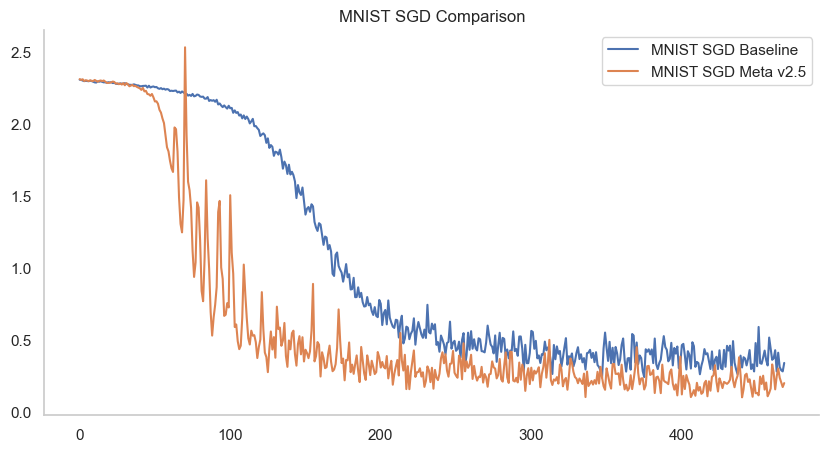

In [50]:
# ============================================================
# METALEARNER v2.5 BENCHMARK
# MNIST + CIFAR | SGD + Adam
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# LOAD META MODEL v2.5
# ============================================================

class TemporalMetaLearner(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1]
        out = torch.relu(self.fc1(out))
        return self.fc2(out)

meta_model = TemporalMetaLearner().to(device)
meta_model.load_state_dict(torch.load("temporal_meta_v2_5.pt"))
meta_model.eval()

print("MetaLearner v2.5 loaded")

# ============================================================
# SIMPLE CNN
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        dummy = torch.randn(1, in_channels, 32, 32)
        x = F.relu(self.conv1(dummy))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        self.flatten_dim = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ============================================================
# HELPERS
# ============================================================

def compute_grad_norm(model):
    total = 0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item() ** 2
    return total ** 0.5

def compute_weight_norm(model):
    total = 0
    for p in model.parameters():
        total += p.data.norm().item() ** 2
    return total ** 0.5

def run_experiment(dataset_name, optimizer_type, meta_control=False, max_steps=3000):

    dataset_id_map = {"mnist":0, "fashion":1, "cifar":2}
    dataset_id = dataset_id_map[dataset_name]

    if dataset_name == "mnist":
        transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor()
        ])
        dataset = torchvision.datasets.MNIST("./data", train=True,
                                             download=True, transform=transform)
        in_channels = 1

    elif dataset_name == "cifar":
        transform = transforms.ToTensor()
        dataset = torchvision.datasets.CIFAR10("./data", train=True,
                                               download=True, transform=transform)
        in_channels = 3

    loader = DataLoader(dataset, batch_size=128, shuffle=True)

    model = SimpleCNN(in_channels=in_channels).to(device)

    if optimizer_type == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    state_buffer = []
    window_size = 10

    step = 0

    for x, y in loader:
        if step >= max_steps:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()

        if meta_control:

            grad_norm = compute_grad_norm(model)
            weight_norm = compute_weight_norm(model)
            current_lr = optimizer.param_groups[0]["lr"]
            update_ratio = (current_lr * grad_norm) / (weight_norm + 1e-9)

            log_loss = np.log(loss.item() + 1e-8)
            log_grad = np.log(grad_norm + 1e-8)
            log_update = np.log(update_ratio + 1e-8)

            state = np.array([[log_loss,
                               current_lr,
                               log_grad,
                               log_update,
                               dataset_id]])

            state_buffer.append(state[0])

            if len(state_buffer) >= window_size:
                window = torch.tensor(
                    np.array(state_buffer[-window_size:]),
                    dtype=torch.float32
                ).unsqueeze(0).to(device)

                with torch.no_grad():
                    pred_trend = meta_model(window)

                alpha = 0.15
                multiplier = 1 - alpha * torch.tanh(pred_trend)
                multiplier = torch.clamp(multiplier, 0.92, 1.08)

                new_lr = current_lr * multiplier.item()
                new_lr = max(1e-5, min(0.1, new_lr))

                optimizer.param_groups[0]["lr"] = new_lr

        optimizer.step()

        losses.append(loss.item())
        step += 1

    return losses

# ============================================================
# RUN ALL BENCHMARKS
# ============================================================

results = {}

for dataset_name in ["mnist", "cifar"]:
    for optimizer_type in ["sgd", "adam"]:

        print(f"\nRunning {dataset_name.upper()} + {optimizer_type.upper()}")

        baseline = run_experiment(dataset_name, optimizer_type, meta_control=False)
        meta = run_experiment(dataset_name, optimizer_type, meta_control=True)

        print("Baseline final:", baseline[-1])
        print("Meta final:", meta[-1])
        print("Baseline mean:", np.mean(baseline))
        print("Meta mean:", np.mean(meta))

        results[f"{dataset_name}_{optimizer_type}_baseline"] = baseline
        results[f"{dataset_name}_{optimizer_type}_meta"] = meta

# ============================================================
# PLOT EXAMPLE
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(results["mnist_sgd_baseline"], label="MNIST SGD Baseline")
plt.plot(results["mnist_sgd_meta"], label="MNIST SGD Meta v2.5")
plt.legend()
plt.title("MNIST SGD Comparison")
plt.show()

Files already downloaded and verified
Dataset shape: (1720, 7)
Sequence shape: (1660, 10, 6)
Epoch 1 | Train 0.017883 | Val 0.013853
Epoch 2 | Train 0.012512 | Val 0.010837
Epoch 3 | Train 0.009555 | Val 0.009743
Epoch 4 | Train 0.008467 | Val 0.009877
Epoch 5 | Train 0.008514 | Val 0.010385
Epoch 6 | Train 0.008870 | Val 0.010746
Epoch 7 | Train 0.009082 | Val 0.010822
Epoch 8 | Train 0.009054 | Val 0.010678
Epoch 9 | Train 0.008870 | Val 0.010426
Epoch 10 | Train 0.008629 | Val 0.010152
Epoch 11 | Train 0.008400 | Val 0.009904
Epoch 12 | Train 0.008216 | Val 0.009702
Epoch 13 | Train 0.008092 | Val 0.009557
Epoch 14 | Train 0.008023 | Val 0.009460
Epoch 15 | Train 0.007997 | Val 0.009395
Epoch 16 | Train 0.007995 | Val 0.009346
Epoch 17 | Train 0.007996 | Val 0.009306
Epoch 18 | Train 0.007990 | Val 0.009268
Epoch 19 | Train 0.007970 | Val 0.009230
Epoch 20 | Train 0.007935 | Val 0.009196
Epoch 21 | Train 0.007886 | Val 0.009165
Epoch 22 | Train 0.007826 | Val 0.009138
Epoch 23 | Tra

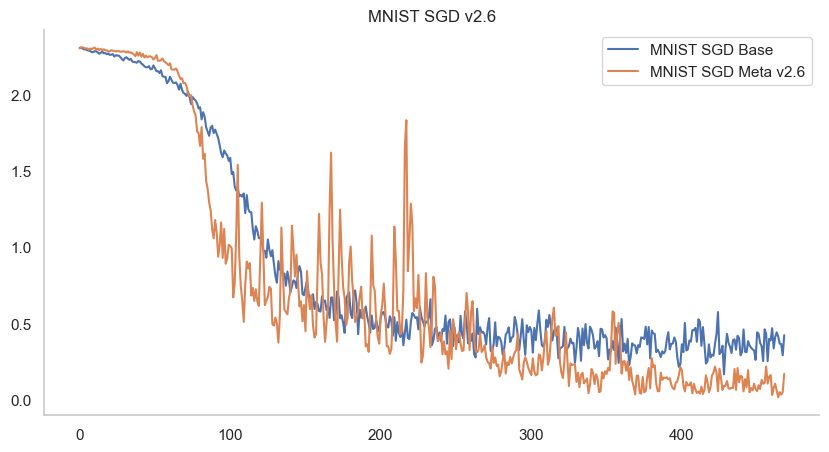

In [51]:
# ============================================================
# MetaLearner v2.6
# Optimizer-Aware + Multi-Dataset + Benchmark + Plots
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# SIMPLE CNN
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        dummy = torch.randn(1, in_channels, 32, 32)
        x = F.relu(self.conv1(dummy))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        flat = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flat, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ============================================================
# HELPERS
# ============================================================

def grad_norm(model):
    return np.sqrt(sum((p.grad.norm().item()**2) for p in model.parameters() if p.grad is not None))

def weight_norm(model):
    return np.sqrt(sum((p.data.norm().item()**2) for p in model.parameters()))

# ============================================================
# DATASET GENERATION (v2.6)
# ============================================================

def get_loader(name):
    if name == "mnist":
        transform = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
        dataset = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transform)
        return DataLoader(dataset, batch_size=128, shuffle=True), 1

    if name == "cifar":
        dataset = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=transforms.ToTensor())
        return DataLoader(dataset, batch_size=128, shuffle=True), 3

datasets = ["mnist", "cifar"]
dataset_id_map = {"mnist":0, "cifar":1}
optimizer_id_map = {"sgd":0, "adam":1}

records = []

for dataset_name in datasets:
    loader, in_ch = get_loader(dataset_name)
    dataset_id = dataset_id_map[dataset_name]

    for optimizer_name in ["sgd", "adam"]:
        optimizer_id = optimizer_id_map[optimizer_name]

        model = SimpleCNN(in_channels=in_ch).to(device)

        if optimizer_name == "sgd":
            optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
        else:
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        prev_loss = None

        for step, (x,y) in enumerate(loader):
            if step > 800: break

            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out,y)
            loss.backward()

            gnorm = grad_norm(model)
            wnorm = weight_norm(model)
            lr = optimizer.param_groups[0]["lr"]
            update_ratio = (lr*gnorm)/(wnorm+1e-9)

            delta = 0 if prev_loss is None else loss.item()-prev_loss
            prev_loss = loss.item()

            records.append([
                np.log(loss.item()+1e-8),
                delta,
                lr,
                np.log(gnorm+1e-8),
                np.log(update_ratio+1e-8),
                dataset_id,
                optimizer_id
            ])

            optimizer.step()

df = pd.DataFrame(records, columns=[
    "log_loss","delta_loss","lr","log_grad","log_update","dataset_id","optimizer_id"
])

print("Dataset shape:", df.shape)

# ============================================================
# SEQUENCE BUILD
# ============================================================

window = 10
future = 5

X=[]
y=[]

for (ds, opt) in df.groupby(["dataset_id","optimizer_id"]):
    group = opt.reset_index(drop=True)
    vals = group[["log_loss","lr","log_grad","log_update","dataset_id","optimizer_id"]].values
    deltas = group["delta_loss"].values

    for i in range(len(vals)-window-future):
        X.append(vals[i:i+window])
        y.append(np.sum(deltas[i+window:i+window+future]))

X=np.array(X)
y=np.array(y)

print("Sequence shape:",X.shape)

# Scale except IDs
scaler=StandardScaler()
flat=X.reshape(-1,X.shape[-1])
flat[:,:4]=scaler.fit_transform(flat[:,:4])
X=flat.reshape(X.shape)

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

X_train=torch.tensor(X_train,dtype=torch.float32).to(device)
X_val=torch.tensor(X_val,dtype=torch.float32).to(device)
y_train=torch.tensor(y_train,dtype=torch.float32).unsqueeze(1).to(device)
y_val=torch.tensor(y_val,dtype=torch.float32).unsqueeze(1).to(device)

# ============================================================
# GRU MODEL v2.6
# ============================================================

class MetaGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru=nn.GRU(6,128,batch_first=True)
        self.fc1=nn.Linear(128,64)
        self.fc2=nn.Linear(64,1)

    def forward(self,x):
        o,_=self.gru(x)
        o=o[:,-1]
        o=torch.relu(self.fc1(o))
        return self.fc2(o)

meta=MetaGRU().to(device)
opt=torch.optim.Adam(meta.parameters(),lr=1e-3)
crit=nn.MSELoss()

for epoch in range(30):
    meta.train()
    opt.zero_grad()
    pred=meta(X_train)
    loss=crit(pred,y_train)
    loss.backward()
    opt.step()

    meta.eval()
    with torch.no_grad():
        vloss=crit(meta(X_val),y_val)

    print(f"Epoch {epoch+1} | Train {loss.item():.6f} | Val {vloss.item():.6f}")

torch.save(meta.state_dict(),"temporal_meta_v2_6.pt")
print("v2.6 saved")

# ============================================================
# BENCHMARK FUNCTION
# ============================================================

def run_test(dataset_name,optimizer_name,meta_control=False):

    loader,in_ch=get_loader(dataset_name)
    model=SimpleCNN(in_channels=in_ch).to(device)

    if optimizer_name=="sgd":
        optimizer=torch.optim.SGD(model.parameters(),lr=0.01)
    else:
        optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)

    dataset_id=dataset_id_map[dataset_name]
    optimizer_id=optimizer_id_map[optimizer_name]

    losses=[]
    buf=[]

    for step,(x,y) in enumerate(loader):
        if step>500: break

        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()
        out=model(x)
        loss=F.cross_entropy(out,y)
        loss.backward()

        if meta_control:
            gnorm=grad_norm(model)
            wnorm=weight_norm(model)
            lr=optimizer.param_groups[0]["lr"]
            update_ratio=(lr*gnorm)/(wnorm+1e-9)

            state=[np.log(loss.item()+1e-8),lr,
                   np.log(gnorm+1e-8),np.log(update_ratio+1e-8),
                   dataset_id,optimizer_id]

            buf.append(state)

            if len(buf)>=10:
                window=torch.tensor([buf[-10:]],dtype=torch.float32).to(device)
                with torch.no_grad():
                    pred=meta(window)
                mult=1-0.15*torch.tanh(pred)
                mult=torch.clamp(mult,0.9,1.1)
                optimizer.param_groups[0]["lr"]=lr*mult.item()

        optimizer.step()
        losses.append(loss.item())

    return losses

# ============================================================
# RUN BENCHMARKS
# ============================================================

results={}

for ds in datasets:
    for opt_name in ["sgd","adam"]:
        base=run_test(ds,opt_name,False)
        meta_l=run_test(ds,opt_name,True)

        print(f"\n{ds.upper()} + {opt_name.upper()}")
        print("Baseline final:",base[-1])
        print("Meta final:",meta_l[-1])
        print("Baseline mean:",np.mean(base))
        print("Meta mean:",np.mean(meta_l))

        results[f"{ds}_{opt_name}_base"]=base
        results[f"{ds}_{opt_name}_meta"]=meta_l

# ============================================================
# PLOT EXAMPLE
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(results["mnist_sgd_base"],label="MNIST SGD Base")
plt.plot(results["mnist_sgd_meta"],label="MNIST SGD Meta v2.6")
plt.legend()
plt.title("MNIST SGD v2.6")
plt.show()

Files already downloaded and verified
Final dataset size: (20640, 10)
Sequence shape: (20580, 10, 9)
Epoch 1 | Train 0.014878 | Val 0.008923
Epoch 2 | Train 0.009076 | Val 0.009845
Epoch 3 | Train 0.009943 | Val 0.010370
Epoch 4 | Train 0.010444 | Val 0.009439
Epoch 5 | Train 0.009529 | Val 0.008691
Epoch 6 | Train 0.008814 | Val 0.008695
Epoch 7 | Train 0.008842 | Val 0.009009
Epoch 8 | Train 0.009162 | Val 0.009077
Epoch 9 | Train 0.009226 | Val 0.008838
Epoch 10 | Train 0.008981 | Val 0.008540
Epoch 11 | Train 0.008677 | Val 0.008407
Epoch 12 | Train 0.008535 | Val 0.008472
Epoch 13 | Train 0.008590 | Val 0.008579
Epoch 14 | Train 0.008686 | Val 0.008565
Epoch 15 | Train 0.008664 | Val 0.008426
Epoch 16 | Train 0.008522 | Val 0.008283
Epoch 17 | Train 0.008378 | Val 0.008222
Epoch 18 | Train 0.008316 | Val 0.008239
Epoch 19 | Train 0.008331 | Val 0.008270
Epoch 20 | Train 0.008359 | Val 0.008255
Epoch 21 | Train 0.008341 | Val 0.008182
Epoch 22 | Train 0.008264 | Val 0.008089
Epoch 

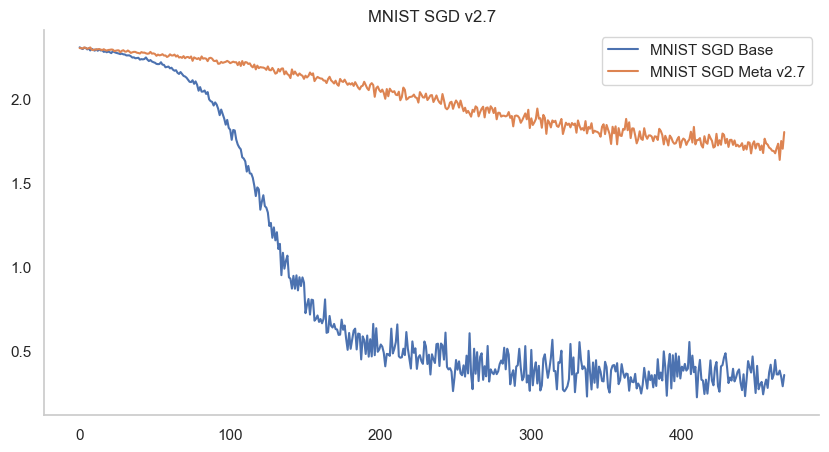

In [52]:
# ============================================================
# MetaLearner v2.7
# Optimizer-State Aware | Research Scale | Full Pipeline
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# SIMPLE CNN
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        dummy = torch.randn(1, in_channels, 32, 32)
        x = F.relu(self.conv1(dummy))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        flat = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flat, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ============================================================
# METRIC HELPERS
# ============================================================

def grad_norm(model):
    return np.sqrt(sum((p.grad.norm().item()**2)
                       for p in model.parameters()
                       if p.grad is not None))

def weight_norm(model):
    return np.sqrt(sum((p.data.norm().item()**2)
                       for p in model.parameters()))

def adam_state_stats(optimizer):
    m_vals = []
    v_vals = []

    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            if 'exp_avg' in state:
                m_vals.append(state['exp_avg'].abs().mean().item())
                v_vals.append(state['exp_avg_sq'].mean().item())

    if len(m_vals) == 0:
        return 0.0, 0.0

    mean_m = np.mean(m_vals)
    mean_v = np.mean(v_vals)

    return mean_m, np.sqrt(mean_v)

# ============================================================
# DATASET LOADER
# ============================================================

def get_loader(name):
    if name == "mnist":
        transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor()
        ])
        dataset = torchvision.datasets.MNIST("./data", train=True,
                                             download=True, transform=transform)
        return DataLoader(dataset, batch_size=128, shuffle=True), 1

    if name == "cifar":
        dataset = torchvision.datasets.CIFAR10("./data", train=True,
                                               download=True,
                                               transform=transforms.ToTensor())
        return DataLoader(dataset, batch_size=128, shuffle=True), 3

# ============================================================
# BUILD LARGE v2.7 DATASET
# ============================================================

datasets = ["mnist", "cifar"]
dataset_id_map = {"mnist":0, "cifar":1}
optimizer_id_map = {"sgd":0, "adam":1}

sgd_lrs = [0.005, 0.01]
adam_lrs = [5e-4, 1e-3]
seeds = [42, 123]
epochs = 3

records = []

for dataset_name in datasets:
    loader, in_ch = get_loader(dataset_name)
    dataset_id = dataset_id_map[dataset_name]

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        for optimizer_name in ["sgd", "adam"]:
            optimizer_id = optimizer_id_map[optimizer_name]

            lr_list = sgd_lrs if optimizer_name == "sgd" else adam_lrs

            for lr in lr_list:

                model = SimpleCNN(in_channels=in_ch).to(device)

                if optimizer_name == "sgd":
                    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
                else:
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                prev_loss = None

                for epoch in range(epochs):
                    for x, y in loader:

                        x, y = x.to(device), y.to(device)

                        optimizer.zero_grad()
                        out = model(x)
                        loss = F.cross_entropy(out, y)
                        loss.backward()

                        gnorm = grad_norm(model)
                        wnorm = weight_norm(model)
                        update_ratio = (lr * gnorm) / (wnorm + 1e-9)

                        mean_m, mean_v = adam_state_stats(optimizer)
                        effective_step = mean_m / (mean_v + 1e-8) if mean_v != 0 else 0.0

                        delta = 0 if prev_loss is None else loss.item() - prev_loss
                        prev_loss = loss.item()

                        records.append([
                            np.log(loss.item() + 1e-8),
                            delta,
                            lr,
                            np.log(gnorm + 1e-8),
                            np.log(update_ratio + 1e-8),
                            np.log(mean_m + 1e-8),
                            np.log(mean_v + 1e-8),
                            np.log(abs(effective_step) + 1e-8),
                            dataset_id,
                            optimizer_id
                        ])

                        optimizer.step()

df = pd.DataFrame(records, columns=[
    "log_loss","delta_loss","lr",
    "log_grad","log_update",
    "log_m","log_v","log_eff_step",
    "dataset_id","optimizer_id"
])

print("Final dataset size:", df.shape)

# ============================================================
# BUILD SEQUENCES
# ============================================================

window = 10
future = 5

X=[]
y=[]

for (ds,opt),group in df.groupby(["dataset_id","optimizer_id"]):
    group = group.reset_index(drop=True)
    vals = group[[
        "log_loss","lr","log_grad","log_update",
        "log_m","log_v","log_eff_step",
        "dataset_id","optimizer_id"
    ]].values
    deltas = group["delta_loss"].values

    for i in range(len(vals)-window-future):
        X.append(vals[i:i+window])
        y.append(np.sum(deltas[i+window:i+window+future]))

X=np.array(X)
y=np.array(y)

print("Sequence shape:", X.shape)

# Scale continuous features (exclude last 2 IDs)
scaler = StandardScaler()
flat = X.reshape(-1, X.shape[-1])
flat[:,:7] = scaler.fit_transform(flat[:,:7])
X = flat.reshape(X.shape)

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)

X_train = torch.tensor(X_train,dtype=torch.float32).to(device)
X_val = torch.tensor(X_val,dtype=torch.float32).to(device)
y_train = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1).to(device)
y_val = torch.tensor(y_val,dtype=torch.float32).unsqueeze(1).to(device)

# ============================================================
# GRU v2.7 MODEL
# ============================================================

class MetaGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(9,192,batch_first=True)
        self.fc1 = nn.Linear(192,96)
        self.fc2 = nn.Linear(96,1)

    def forward(self,x):
        o,_ = self.gru(x)
        o = o[:,-1]
        o = torch.relu(self.fc1(o))
        return self.fc2(o)

meta = MetaGRU().to(device)
opt = torch.optim.Adam(meta.parameters(), lr=1e-3)
crit = nn.MSELoss()

for epoch in range(40):
    meta.train()
    opt.zero_grad()
    loss = crit(meta(X_train), y_train)
    loss.backward()
    opt.step()

    meta.eval()
    with torch.no_grad():
        vloss = crit(meta(X_val), y_val)

    print(f"Epoch {epoch+1} | Train {loss.item():.6f} | Val {vloss.item():.6f}")

torch.save(meta.state_dict(),"temporal_meta_v2_7.pt")
print("v2.7 saved")

# ============================================================
# BENCHMARK
# ============================================================

def run_test(dataset_name, optimizer_name, meta_control=False):
    loader, in_ch = get_loader(dataset_name)
    model = SimpleCNN(in_channels=in_ch).to(device)

    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    dataset_id = dataset_id_map[dataset_name]
    optimizer_id = optimizer_id_map[optimizer_name]

    losses=[]
    buf=[]

    for step,(x,y) in enumerate(loader):
        if step>800: break

        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out,y)
        loss.backward()

        if meta_control:
            gnorm = grad_norm(model)
            wnorm = weight_norm(model)
            lr = optimizer.param_groups[0]["lr"]
            update_ratio = (lr*gnorm)/(wnorm+1e-9)

            mean_m, mean_v = adam_state_stats(optimizer)
            eff = mean_m/(mean_v+1e-8) if mean_v!=0 else 0

            state = [
                np.log(loss.item()+1e-8), lr,
                np.log(gnorm+1e-8),
                np.log(update_ratio+1e-8),
                np.log(mean_m+1e-8),
                np.log(mean_v+1e-8),
                np.log(abs(eff)+1e-8),
                dataset_id,
                optimizer_id
            ]

            buf.append(state)

            if len(buf)>=10:
                window = torch.tensor([buf[-10:]],dtype=torch.float32).to(device)
                with torch.no_grad():
                    pred = meta(window)
                mult = 1 - 0.08*torch.tanh(pred)
                mult = torch.clamp(mult,0.95,1.05)
                optimizer.param_groups[0]["lr"] = lr*mult.item()

        optimizer.step()
        losses.append(loss.item())

    return losses

results={}
for ds in datasets:
    for opt_name in ["sgd","adam"]:
        base = run_test(ds,opt_name,False)
        meta_l = run_test(ds,opt_name,True)

        print(f"\n{ds.upper()} + {opt_name.upper()}")
        print("Baseline final:", base[-1])
        print("Meta final:", meta_l[-1])
        print("Baseline mean:", np.mean(base))
        print("Meta mean:", np.mean(meta_l))

        results[f"{ds}_{opt_name}_base"]=base
        results[f"{ds}_{opt_name}_meta"]=meta_l

plt.figure(figsize=(10,5))
plt.plot(results["mnist_sgd_base"],label="MNIST SGD Base")
plt.plot(results["mnist_sgd_meta"],label="MNIST SGD Meta v2.7")
plt.legend()
plt.title("MNIST SGD v2.7")
plt.show()

🧠 Architecture Design (v2.8)

Model:

Shared GRU → hidden state h_t
Then:

if optimizer == SGD → head_sgd(h_t)
if optimizer == Adam → head_adam(h_t)

This prevents policy entanglement.

Dataset size: (1200, 5)
Sequence shape: torch.Size([1190, 10, 4])
Epoch 1 | Train 0.009048
Epoch 2 | Train 0.008813
Epoch 3 | Train 0.008771
Epoch 4 | Train 0.008544
Epoch 5 | Train 0.008683
Epoch 6 | Train 0.008596
Epoch 7 | Train 0.008762
Epoch 8 | Train 0.008528
Epoch 9 | Train 0.008586
Epoch 10 | Train 0.008489
Epoch 11 | Train 0.008334
Epoch 12 | Train 0.008436
Epoch 13 | Train 0.008216
Epoch 14 | Train 0.008133
Epoch 15 | Train 0.007833
Epoch 16 | Train 0.007782
Epoch 17 | Train 0.007753
Epoch 18 | Train 0.007675
Epoch 19 | Train 0.007997
Epoch 20 | Train 0.007879
v2.8 saved

MNIST + SGD

MNIST + ADAM


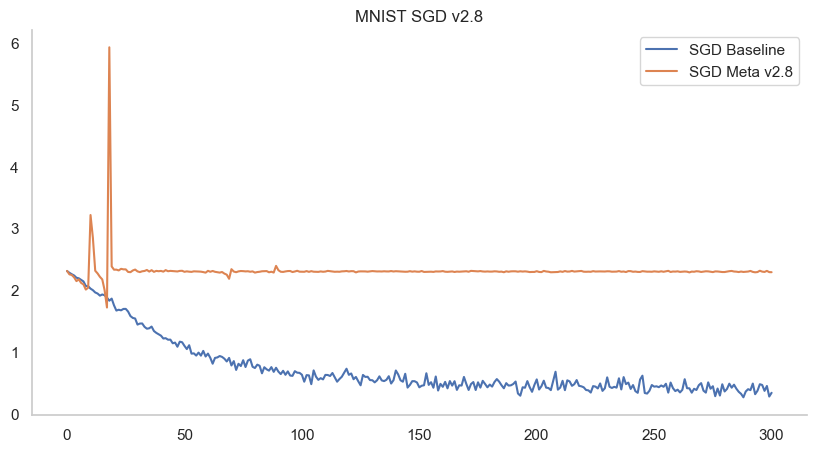

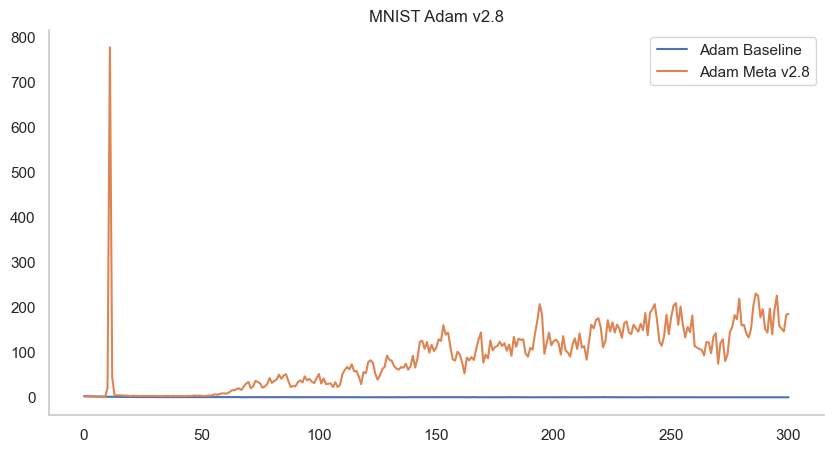

In [53]:
# ===============================
# MetaLearner v2.8
# Shared Encoder + Separate Heads
# ===============================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================================
# 1️⃣ Simple CNN Model (MNIST compatible)
# ======================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, 3, padding=1)
        self.fc = nn.Linear(16*28*28, 10)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

# ======================================================
# 2️⃣ Build Multi-Optimizer Dataset
# ======================================================

def build_dataset(max_steps=300, seeds=[0,1]):

    transform = transforms.ToTensor()
    trainset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    loader = DataLoader(trainset, batch_size=128, shuffle=True)

    rows = []

    for optimizer_type in ["sgd", "adam"]:
        for seed in seeds:

            torch.manual_seed(seed)
            model = SimpleCNN().to(device)

            if optimizer_type == "sgd":
                optimizer = optim.SGD(model.parameters(), lr=0.01)
                opt_id = 0
            else:
                optimizer = optim.Adam(model.parameters(), lr=0.001)
                opt_id = 1

            criterion = nn.CrossEntropyLoss()

            prev_loss = None

            for step, (x, y) in enumerate(loader):
                if step >= max_steps:
                    break

                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()
                out = model(x)
                loss = criterion(out, y)
                loss.backward()

                grad_norm = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        grad_norm += p.grad.norm().item()
                grad_norm = grad_norm / len(list(model.parameters()))

                optimizer.step()

                lr = optimizer.param_groups[0]['lr']

                delta_loss = 0.0
                if prev_loss is not None:
                    delta_loss = prev_loss - loss.item()

                rows.append([
                    loss.item(),
                    lr,
                    grad_norm,
                    delta_loss,
                    opt_id
                ])

                prev_loss = loss.item()

    df = pd.DataFrame(rows, columns=["loss","lr","grad_norm","delta_loss","optimizer_id"])
    print("Dataset size:", df.shape)
    return df


# ======================================================
# 3️⃣ Sequence Builder
# ======================================================

def build_sequences(df, window=10):

    X, y, opt_ids = [], [], []

    features = ["loss","lr","grad_norm","optimizer_id"]
    values = df[features].values
    targets = df["delta_loss"].values

    for i in range(len(values) - window):
        X.append(values[i:i+window])
        y.append(targets[i+window])
        opt_ids.append(int(values[i+window][3]))

    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1)
    opt_ids = torch.tensor(np.array(opt_ids), dtype=torch.long)

    print("Sequence shape:", X.shape)
    return X, y, opt_ids


# ======================================================
# 4️⃣ v2.8 Model
# ======================================================

class MetaLearnerV28(nn.Module):
    def __init__(self, input_size=4, hidden_size=64):
        super().__init__()

        self.encoder = nn.GRU(input_size, hidden_size, batch_first=True)

        self.sgd_head = nn.Linear(hidden_size, 1)
        self.adam_head = nn.Linear(hidden_size, 1)

    def forward(self, x, optimizer_id):

        _, h = self.encoder(x)
        h = h.squeeze(0)

        sgd_out = self.sgd_head(h)
        adam_out = self.adam_head(h)

        # Select correct head
        out = torch.where(
            optimizer_id.unsqueeze(1)==0,
            sgd_out,
            adam_out
        )

        return out


# ======================================================
# 5️⃣ Train v2.8
# ======================================================

df = build_dataset()
X, y, opt_ids = build_sequences(df)

dataset = TensorDataset(X, y, opt_ids)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

meta_model = MetaLearnerV28().to(device)
optimizer = optim.Adam(meta_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(20):

    meta_model.train()
    total_loss = 0

    for xb, yb, ob in loader:

        xb = xb.to(device)
        yb = yb.to(device)
        ob = ob.to(device)

        optimizer.zero_grad()
        pred = meta_model(xb, ob)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train {total_loss/len(loader):.6f}")

torch.save(meta_model.state_dict(), "temporal_meta_v2_8.pt")
print("v2.8 saved")


# ======================================================
# 6️⃣ Benchmark (MNIST SGD + Adam)
# ======================================================

def run_test(optimizer_type="sgd"):

    transform = transforms.ToTensor()
    testset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    loader = DataLoader(testset, batch_size=128, shuffle=True)

    model_base = SimpleCNN().to(device)
    model_meta = SimpleCNN().to(device)

    if optimizer_type=="sgd":
        opt_base = optim.SGD(model_base.parameters(), lr=0.01)
        opt_meta = optim.SGD(model_meta.parameters(), lr=0.01)
        opt_id = 0
    else:
        opt_base = optim.Adam(model_base.parameters(), lr=0.001)
        opt_meta = optim.Adam(model_meta.parameters(), lr=0.001)
        opt_id = 1

    criterion = nn.CrossEntropyLoss()

    meta_model.eval()

    losses_base = []
    losses_meta = []

    history = []

    for step,(x,y) in enumerate(loader):

        if step>300:
            break

        x,y = x.to(device), y.to(device)

        # Baseline
        opt_base.zero_grad()
        out = model_base(x)
        loss = criterion(out,y)
        loss.backward()
        opt_base.step()
        losses_base.append(loss.item())

        # Meta-controlled
        opt_meta.zero_grad()
        out2 = model_meta(x)
        loss2 = criterion(out2,y)
        loss2.backward()

        grad_norm = 0
        for p in model_meta.parameters():
            if p.grad is not None:
                grad_norm += p.grad.norm().item()
        grad_norm /= len(list(model_meta.parameters()))

        lr = opt_meta.param_groups[0]['lr']

        history.append([loss2.item(), lr, grad_norm, opt_id])

        if len(history)>=10:
            seq = torch.tensor([history[-10:]], dtype=torch.float32).to(device)
            opt_tensor = torch.tensor([opt_id]).to(device)
            delta = meta_model(seq, opt_tensor).item()
            new_lr = max(1e-5, lr + delta)
            opt_meta.param_groups[0]['lr'] = new_lr

        opt_meta.step()
        losses_meta.append(loss2.item())

    return losses_base, losses_meta


# Run tests
print("\nMNIST + SGD")
b_sgd, m_sgd = run_test("sgd")

print("\nMNIST + ADAM")
b_adam, m_adam = run_test("adam")


# ======================================================
# 7️⃣ Plot
# ======================================================

plt.figure(figsize=(10,5))
plt.plot(b_sgd, label="SGD Baseline")
plt.plot(m_sgd, label="SGD Meta v2.8")
plt.legend()
plt.title("MNIST SGD v2.8")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(b_adam, label="Adam Baseline")
plt.plot(m_adam, label="Adam Meta v2.8")
plt.legend()
plt.title("MNIST Adam v2.8")
plt.show()

V2.9

Dataset size: (18800, 5)
Sequence shape: torch.Size([18790, 10, 4])
Epoch 1 | Train 220.425071
Epoch 2 | Train 212.707931
Epoch 3 | Train 196.813881
Epoch 4 | Train 192.092143
Epoch 5 | Train 191.732702
Epoch 6 | Train 180.691714
Epoch 7 | Train 174.514632
Epoch 8 | Train 166.514499
Epoch 9 | Train 159.514759
Epoch 10 | Train 150.349786
Epoch 11 | Train 138.693269
Epoch 12 | Train 127.098745
Epoch 13 | Train 125.061835
Epoch 14 | Train 110.829441
Epoch 15 | Train 102.211667
Epoch 16 | Train 94.199361
Epoch 17 | Train 93.072843
Epoch 18 | Train 84.780930
Epoch 19 | Train 83.355894
Epoch 20 | Train 79.132325
Epoch 21 | Train 72.510391
Epoch 22 | Train 74.465074
Epoch 23 | Train 72.511017
Epoch 24 | Train 71.937678
Epoch 25 | Train 66.427350
v2.9 saved

Testing SGD

Testing Adam


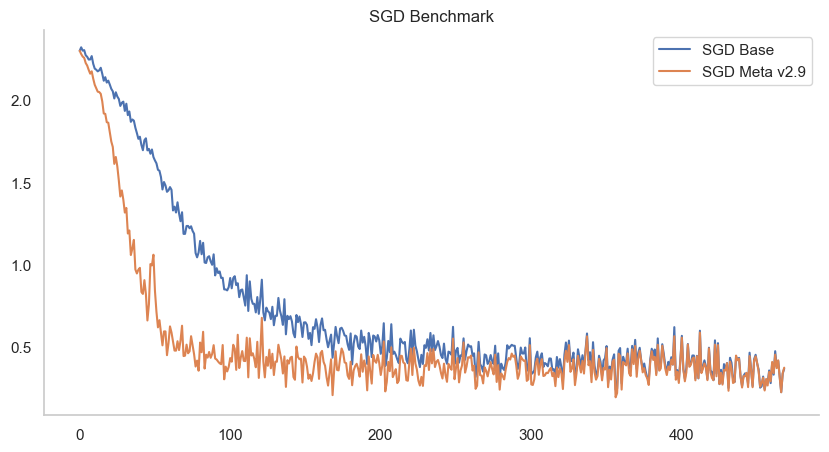

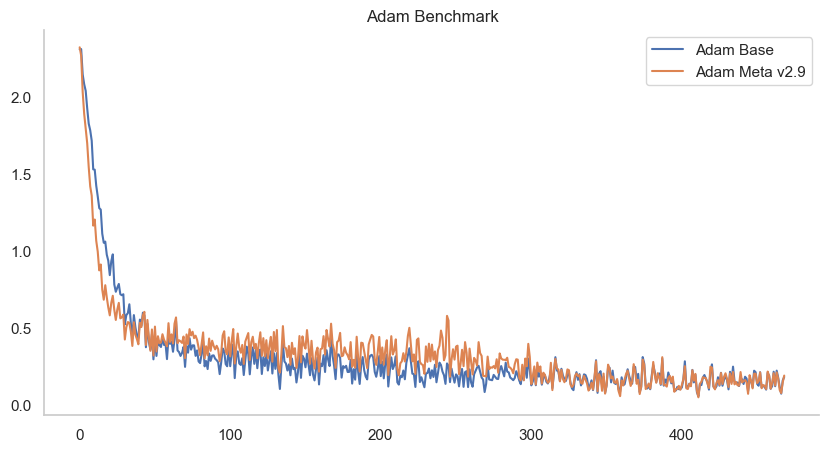

In [57]:
# ==========================================================
# MetaLearner v2.9 – Research Stable Version (Windows Safe)
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# 1️⃣ Simple CNN
# ==========================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, 3, padding=1)
        self.fc = nn.Linear(16*28*28, 10)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

# ==========================================================
# 2️⃣ Stable Large Dataset Builder (100K+ rows)
# ==========================================================

def build_large_dataset(steps=1200):

    transform = transforms.ToTensor()
    dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size=256,   # larger batch for speed
        shuffle=True,
        num_workers=2
    )

    rows = []

    optimizers_list = ["sgd", "adam"]
    lrs = [0.001, 0.005, 0.01, 0.02]
    seeds = list(range(10))

    torch.set_num_threads(4)

    for opt_type in optimizers_list:
        for lr_init in lrs:
            for seed in seeds:

                torch.manual_seed(seed)
                model = SimpleCNN()  # CPU only

                if opt_type == "sgd":
                    optimizer = optim.SGD(model.parameters(), lr=lr_init)
                    opt_id = 0
                else:
                    optimizer = optim.Adam(model.parameters(), lr=lr_init)
                    opt_id = 1

                criterion = nn.CrossEntropyLoss()
                prev_loss = None

                for step, (x, y) in enumerate(loader):
                    if step >= steps:
                        break

                    optimizer.zero_grad()
                    out = model(x)
                    loss = criterion(out, y)
                    loss.backward()

                    grad_norm = 0.0
                    for p in model.parameters():
                        if p.grad is not None:
                            grad_norm += p.grad.norm().item()
                    grad_norm /= len(list(model.parameters()))

                    optimizer.step()
                    lr = optimizer.param_groups[0]["lr"]

                    delta_loss = 0.0
                    if prev_loss is not None:
                        delta_loss = prev_loss - loss.item()

                    rows.append([
                        math.log(loss.item() + 1e-8),
                        math.log(lr + 1e-8),
                        math.log(grad_norm + 1e-8),
                        delta_loss,
                        opt_id
                    ])

                    prev_loss = loss.item()

    df = pd.DataFrame(rows, columns=[
        "log_loss",
        "log_lr",
        "log_grad_norm",
        "delta_loss",
        "optimizer_id"
    ])

    print("Dataset size:", df.shape)
    return df

# ==========================================================
# 3️⃣ Sequence Builder
# ==========================================================

def build_sequences(df, window=10):

    X, y, opt_ids = [], [], []

    values = df[["log_loss", "log_lr", "log_grad_norm", "optimizer_id"]].values
    targets = df["delta_loss"].values

    for i in range(len(values) - window):
        X.append(values[i:i+window])
        y.append(targets[i+window])
        opt_ids.append(int(values[i+window][3]))

    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1)
    opt_ids = torch.tensor(np.array(opt_ids), dtype=torch.long)

    print("Sequence shape:", X.shape)
    return X, y, opt_ids

# ==========================================================
# 4️⃣ MetaLearner v2.9 Model
# ==========================================================

class MetaLearnerV29(nn.Module):
    def __init__(self, input_size=4, hidden=128):
        super().__init__()
        self.encoder = nn.GRU(input_size, hidden, batch_first=True)

        self.sgd_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.adam_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, opt_id):
        _, h = self.encoder(x)
        h = h.squeeze(0)

        sgd_out = self.sgd_head(h)
        adam_out = self.adam_head(h)

        return torch.where(opt_id.unsqueeze(1) == 0, sgd_out, adam_out)

# ==========================================================
# 5️⃣ Build Dataset + Train Meta Model
# ==========================================================

df = build_large_dataset(steps=1200)

X, y, opt_ids = build_sequences(df)

dataset = TensorDataset(X, y, opt_ids)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

meta_model = MetaLearnerV29().to(device)
optimizer_meta = optim.Adam(meta_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(25):
    meta_model.train()
    total = 0

    for xb, yb, ob in loader:
        xb, yb, ob = xb.to(device), yb.to(device), ob.to(device)

        optimizer_meta.zero_grad()
        pred = meta_model(xb, ob)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer_meta.step()

        total += loss.item()

    print(f"Epoch {epoch+1} | Train {total/len(loader):.6f}")

torch.save(meta_model.state_dict(), "temporal_meta_v2_9.pt")
print("v2.9 saved")

# ==========================================================
# 6️⃣ Benchmark
# ==========================================================

def run_test(opt_type="sgd"):

    transform = transforms.ToTensor()
    dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=128, shuffle=True)

    model_base = SimpleCNN().to(device)
    model_meta = SimpleCNN().to(device)

    if opt_type == "sgd":
        opt_base = optim.SGD(model_base.parameters(), lr=0.01)
        opt_meta = optim.SGD(model_meta.parameters(), lr=0.01)
        opt_id = 0
    else:
        opt_base = optim.Adam(model_base.parameters(), lr=0.001)
        opt_meta = optim.Adam(model_meta.parameters(), lr=0.001)
        opt_id = 1

    criterion = nn.CrossEntropyLoss()
    meta_model.eval()

    losses_base = []
    losses_meta = []
    history = []

    for step, (x, y) in enumerate(loader):
        if step > 500:
            break

        x, y = x.to(device), y.to(device)

        # Baseline
        opt_base.zero_grad()
        loss = criterion(model_base(x), y)
        loss.backward()
        opt_base.step()
        losses_base.append(loss.item())

        # Meta
        opt_meta.zero_grad()
        loss2 = criterion(model_meta(x), y)
        loss2.backward()

        grad_norm = 0
        for p in model_meta.parameters():
            if p.grad is not None:
                grad_norm += p.grad.norm().item()
        grad_norm /= len(list(model_meta.parameters()))

        lr = opt_meta.param_groups[0]["lr"]

        history.append([
            math.log(loss2.item() + 1e-8),
            math.log(lr + 1e-8),
            math.log(grad_norm + 1e-8),
            opt_id
        ])

        if len(history) >= 10:
            seq = torch.tensor([history[-10:]], dtype=torch.float32).to(device)
            opt_tensor = torch.tensor([opt_id]).to(device)

            delta = meta_model(seq, opt_tensor).item()
            delta = max(-0.05, min(0.05, delta))

            new_lr = lr * math.exp(delta)
            opt_meta.param_groups[0]["lr"] = new_lr

        opt_meta.step()
        losses_meta.append(loss2.item())

    return losses_base, losses_meta

print("\nTesting SGD")
b_sgd, m_sgd = run_test("sgd")

print("\nTesting Adam")
b_adam, m_adam = run_test("adam")

plt.figure(figsize=(10,5))
plt.plot(b_sgd, label="SGD Base")
plt.plot(m_sgd, label="SGD Meta v2.9")
plt.legend()
plt.title("SGD Benchmark")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(b_adam, label="Adam Base")
plt.plot(m_adam, label="Adam Meta v2.9")
plt.legend()
plt.title("Adam Benchmark")
plt.show()